# Open Smart Home IoT-IEQ-Energy Data Pipeline

This notebook demonstrates the complete pipeline for analyzing smart home sensor data from the Fraunhofer Institute for Building Physics. The pipeline includes:

1. **Data Loading & Exploration**: Load 37 sensor time-series from 6 rooms over 89 days
2. **Data Quality Detection**: Identify drift, missing values, noise, and irregular sampling
3. **Event Abstraction**: Transform sensor patterns into high-level process events
4. **Process Mining**: Discover daily living patterns and HVAC control processes

**Dataset Context**:
- **Domain**: Smart Home / Building Management System
- **Location**: Nuremberg, Germany (March-June 2017)
- **Sensors**: Temperature, Thermostat, Humidity, Brightness, Setpoint, Outdoor Temperature
- **Rooms**: Kitchen, Bathroom, Toilet, Room 1 (Bedroom), Room 2 (Bedroom), Room 3 (Living Room)
- **Process**: Daily living patterns, HVAC control, occupancy detection

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print(" Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Define data path and sensor configuration
data_path = Path('../../data/Open Smart Home IoT-IEQ-Energy Data/Measurements')

# Define rooms and sensor types
rooms = ['Kitchen', 'Bathroom', 'Toilet', 'Room1', 'Room2', 'Room3']
sensor_types = {
    'Temperature': 'temp',         # Wall-mounted temperature sensor
    'ThermostatTemperature': 'tempT',  # Radiator-mounted thermostat temp
    'Humidity': 'humid',           # Relative humidity
    'Brightness': 'brigh',         # Illuminance (lux)
    'SetpointHistory': 'tempS',    # Target temperature
    'OutdoorTemperature': 'outTemp',  # Virtual weather sensor
    'Virtual_OutdoorTemperature': 'outTemp'  # Alternative naming
}

print(f" Configuration loaded")
print(f"  Rooms: {len(rooms)}")
print(f"  Sensor types: {len(set(sensor_types.values()))}")
print(f"  Data path: {data_path}")

✓ Configuration loaded
  Rooms: 6
  Sensor types: 6
  Data path: ../../data/Open Smart Home IoT-IEQ-Energy Data/Measurements


In [3]:
# Load all sensor data files
print(" Loading Open Smart Home sensor data...")
print("   Processing 37 sensor files from 6 rooms...\n")

# Dictionary to store all sensor data
sensor_data = {}

# Get all CSV files
csv_files = list(data_path.glob('*.csv'))
print(f"Found {len(csv_files)} CSV files\n")

# Load each file
for file_path in sorted(csv_files):
    filename = file_path.stem  # Get filename without extension
    
    # Parse filename: Room_SensorType
    parts = filename.split('_', 1)
    if len(parts) == 2:
        room = parts[0]
        sensor_type = parts[1]
    else:
        print(f"  Skipping file with unexpected format: {filename}")
        continue
    
    # Read tab-separated values (no header)
    try:
        df = pd.read_csv(file_path, sep='\t', header=None, names=['timestamp', 'value'])
        
        # Convert UNIX timestamp to datetime
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
        
        # Add metadata
        df['room'] = room
        df['sensor_type'] = sensor_type
        df['sensor_id'] = filename
        
        # Store in dictionary
        sensor_data[filename] = df
        
        print(f" {filename:50s} {len(df):6,} readings")
        
    except Exception as e:
        print(f" Error loading {filename}: {e}")

print(f"\n Loaded {len(sensor_data)} sensor files successfully!")

📂 Loading Open Smart Home sensor data...
   Processing 37 sensor files from 6 rooms...

Found 37 CSV files

✓ Bathroom_Brightness                                11,248 readings
✓ Bathroom_Humidity                                  10,651 readings
✓ Bathroom_SetpointHistory                              344 readings
✓ Bathroom_Temperature                               10,768 readings
✓ Bathroom_ThermostatTemperature                     10,947 readings
✓ Bathroom_Virtual_OutdoorTemperature                 3,710 readings
✓ Kitchen_Brightness                                 10,878 readings
✓ Kitchen_Humidity                                   10,104 readings
✓ Kitchen_SetpointHistory                               357 readings
✓ Kitchen_Temperature                                10,435 readings
✓ Kitchen_ThermostatTemperature                      10,252 readings
✓ Kitchen_Virtual_OutdoorTemperature                  3,710 readings
✓ Room1_Brightness                                   11,038 read

In [4]:
# Combine all data into single DataFrame
print(" Combining all sensor data...\n")

df_all = pd.concat(sensor_data.values(), ignore_index=True)
df_all = df_all.sort_values('timestamp').reset_index(drop=True)

print(f" Dataset consolidated!")
print(f"\nShape: {df_all.shape}")
print(f"Time range: {df_all['timestamp'].min()} to {df_all['timestamp'].max()}")
print(f"Duration: {(df_all['timestamp'].max() - df_all['timestamp'].min()).days} days")
print(f"Rooms: {df_all['room'].nunique()}")
print(f"Sensor types: {df_all['sensor_type'].nunique()}")
print(f"Total readings: {len(df_all):,}")

# Basic statistics
print(f"\n Value statistics:")
print(df_all.groupby('sensor_type')['value'].describe())

🔄 Combining all sensor data...

✅ Dataset consolidated!

Shape: (285954, 5)
Time range: 2017-03-08 23:56:17 to 2017-06-06 04:06:22
Duration: 89 days
Rooms: 6
Sensor types: 9
Total readings: 285,954

📊 Value statistics:
                               count       mean         std    min     25%    50%     75%      max
sensor_type                                                                                       
Brightness                   64629.0  95.345940  159.497828   0.00   0.000  20.14  138.25  1739.56
Humidity                     60456.0  51.381964    7.441318  26.00  46.000  51.00   56.00    98.00
OutdoorTemperature            3710.0  12.758787    6.460711  -2.70   8.125  12.20   17.00    33.00
SetpointHistory               2084.0  18.024472    2.063590  14.50  16.000  18.00   20.00    28.00
Temperature                  62479.0  19.201441    1.601246  14.33  18.270  19.21   20.00    26.14
ThermostatTemperature        52020.0  19.442748    2.420549  13.65  17.880  19.14   20.7

In [5]:
# Display sample data
print("Sample of raw sensor data:\n")
df_all.head(20)

Sample of raw sensor data:



,timestamp,value,room,sensor_type,sensor_id
0,2017-03-08 23:56:17,0.00,Room3,Brightness,Room3_Brightness
1,2017-03-08 23:56:47,6.20,Kitchen,Virtual_OutdoorTemperature,Kitchen_Virtual_OutdoorTemperature
2,2017-03-08 23:56:47,6.20,Bathroom,Virtual_OutdoorTemperature,Bathroom_Virtual_OutdoorTemperature
3,2017-03-08 23:56:47,6.20,Room1,Virtual_OutdoorTemperature,Room1_Virtual_OutdoorTemperature
4,2017-03-08 23:56:47,6.20,Room2,OutdoorTemperature,Room2_OutdoorTemperature
5,2017-03-08 23:56:47,6.20,Room3,Virtual_OutdoorTemperature,Room3_Virtual_OutdoorTemperature
6,2017-03-08 23:56:47,6.20,Toilet,Virtual_OutdoorTemperature,Toilet_Virtual_OutdoorTemperature
7,2017-03-08 23:57:47,22.75,Bathroom,ThermostatTemperature,Bathroom_ThermostatTemperature
8,2017-03-08 23:58:47,0.00,Bathroom,Brightness,Bathroom_Brightness
9,2017-03-08 23:58:47,19.21,Bathroom,Temperature,Bathroom_Temperature


## 2. Data Exploration

Understand the temporal patterns, sensor distributions, and room characteristics.

In [6]:
# Sensor distribution analysis
print(" Sensor Distribution by Room:\n")

sensor_counts = df_all.groupby(['room', 'sensor_type']).size().unstack(fill_value=0)
print(sensor_counts)

print(f"\n Readings per Room:")
room_counts = df_all['room'].value_counts().sort_index()
print(room_counts)

📊 Sensor Distribution by Room:

sensor_type  Brightness  Humidity  OutdoorTemperature  SetpointHistory  Temperature  ThermostatTemperature  Virtual_OutdoorTemperature  left_ThermostatTemperature  right_ThermostatTemperature
room                                                                                                                                                                                           
Bathroom          11248     10651                   0              344        10768                  10947                        3710                           0                            0
Kitchen           10878     10104                   0              357        10435                  10252                        3710                           0                            0
Room1             11038     10329                   0              340        10598                  11025                        3710                           0                            0
Room2   

📈 Sensor Value Distributions by Type



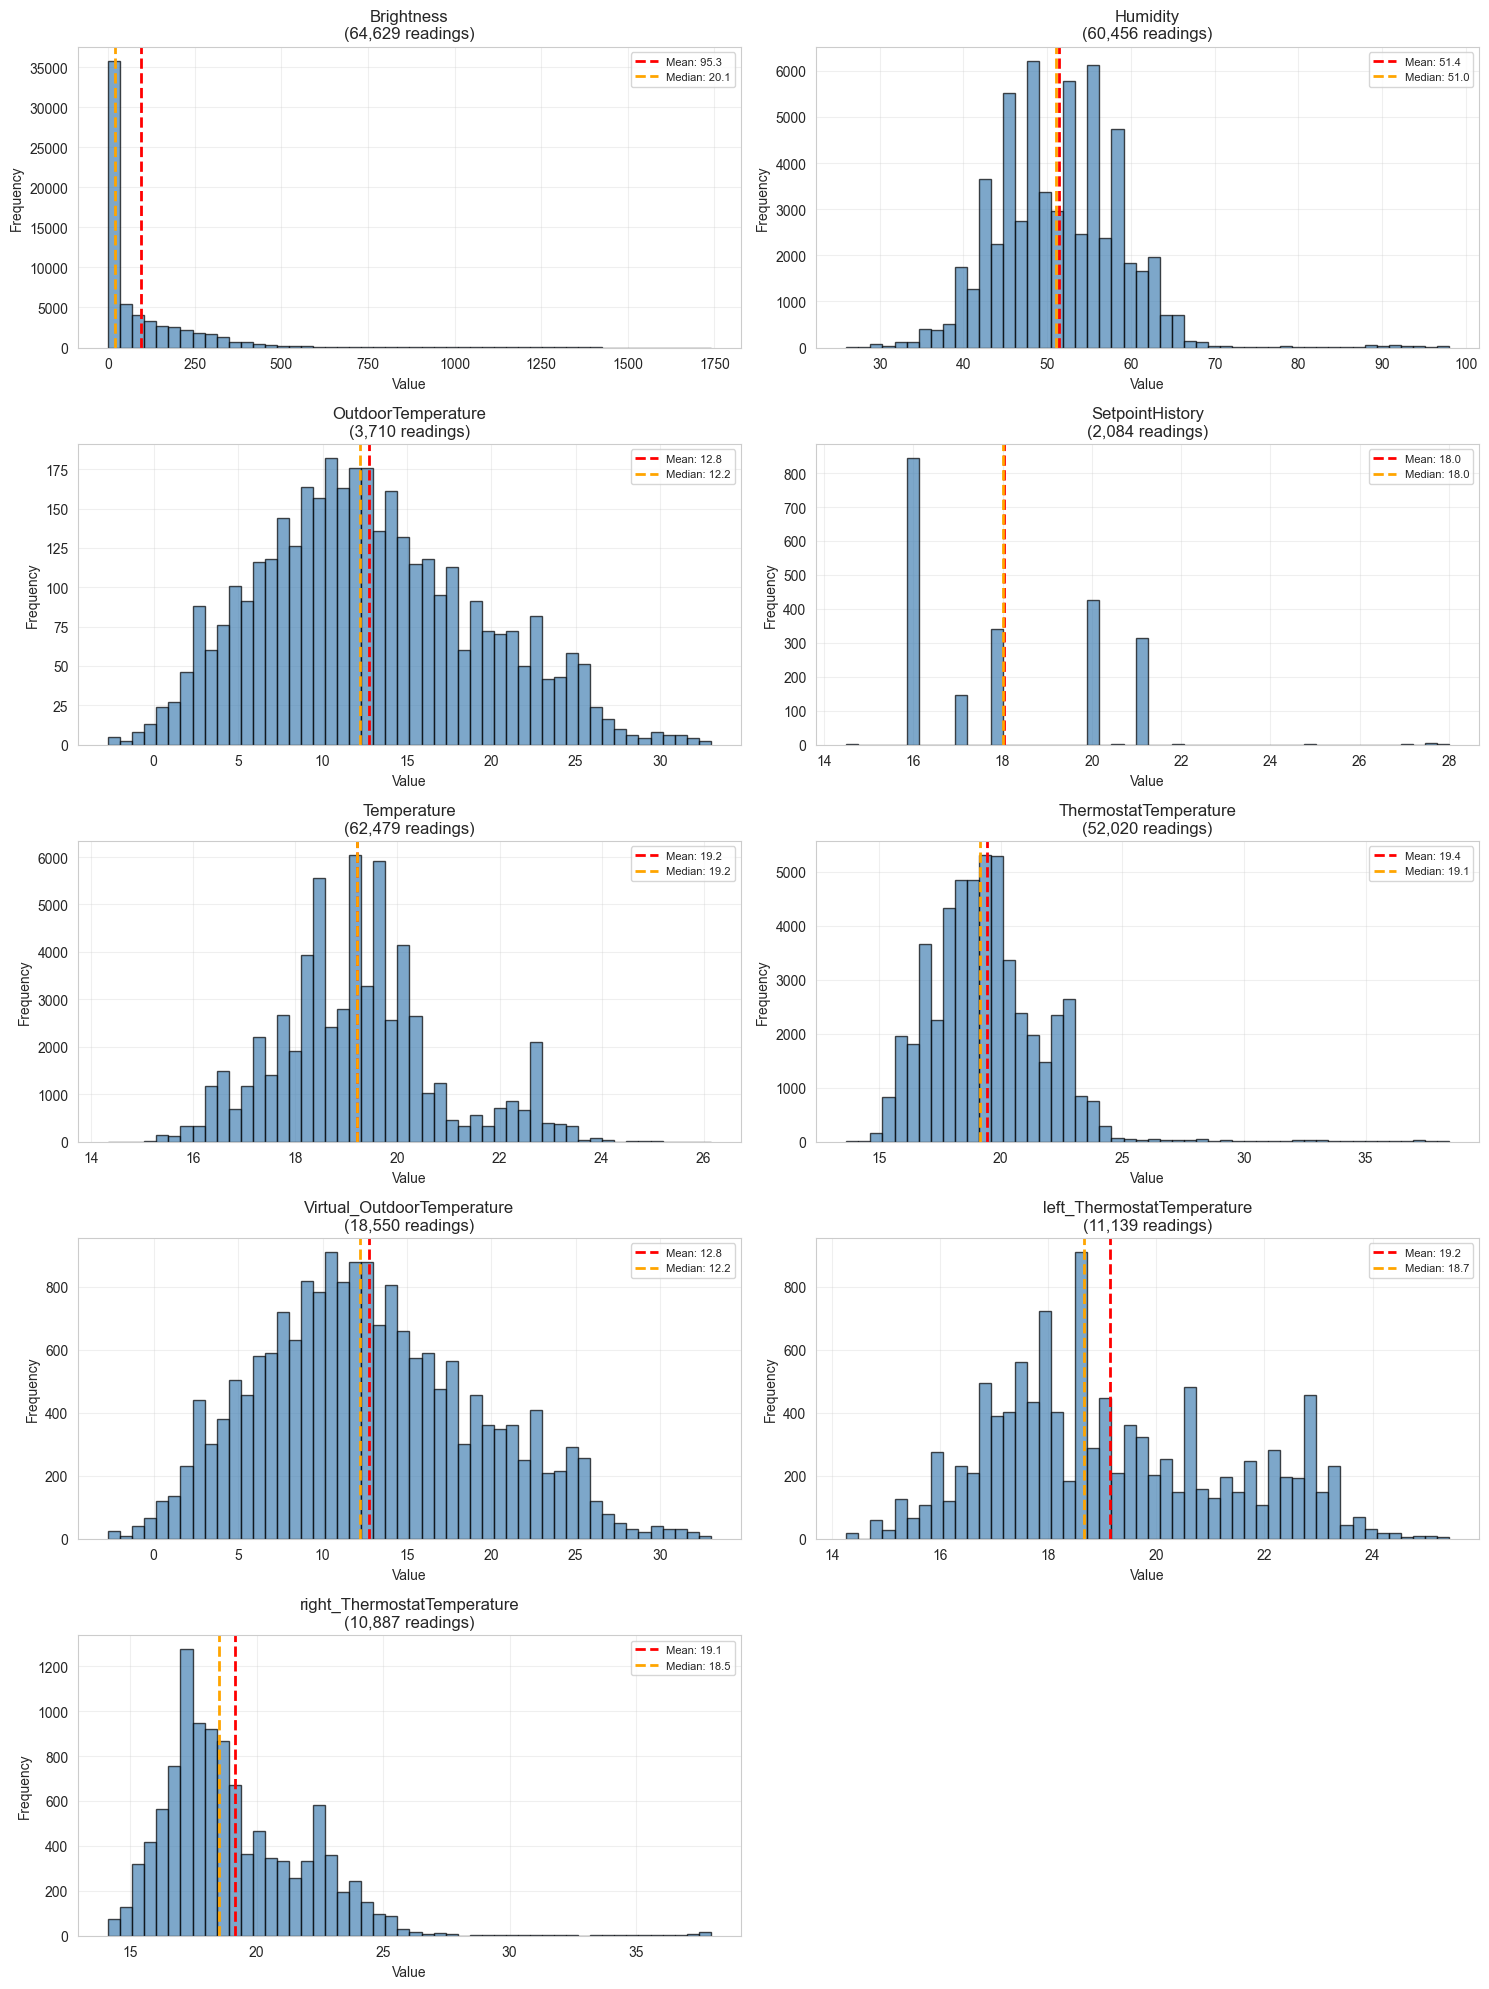

In [7]:
# Visualize sensor readings by type
print(" Sensor Value Distributions by Type\n")

# Get unique sensor types
unique_sensor_types = df_all['sensor_type'].unique()
n_sensors = len(unique_sensor_types)

# Create subplots (2 columns)
n_cols = 2
n_rows = (n_sensors + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for idx, sensor_type in enumerate(sorted(unique_sensor_types)):
    sensor_df = df_all[df_all['sensor_type'] == sensor_type]
    
    ax = axes[idx]
    ax.hist(sensor_df['value'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{sensor_type}\n({len(sensor_df):,} readings)')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = sensor_df['value'].mean()
    median_val = sensor_df['value'].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    ax.legend(fontsize=8)

# Hide unused subplots
for idx in range(n_sensors, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

📈 Visualizing sensor patterns (one week sample per room)...



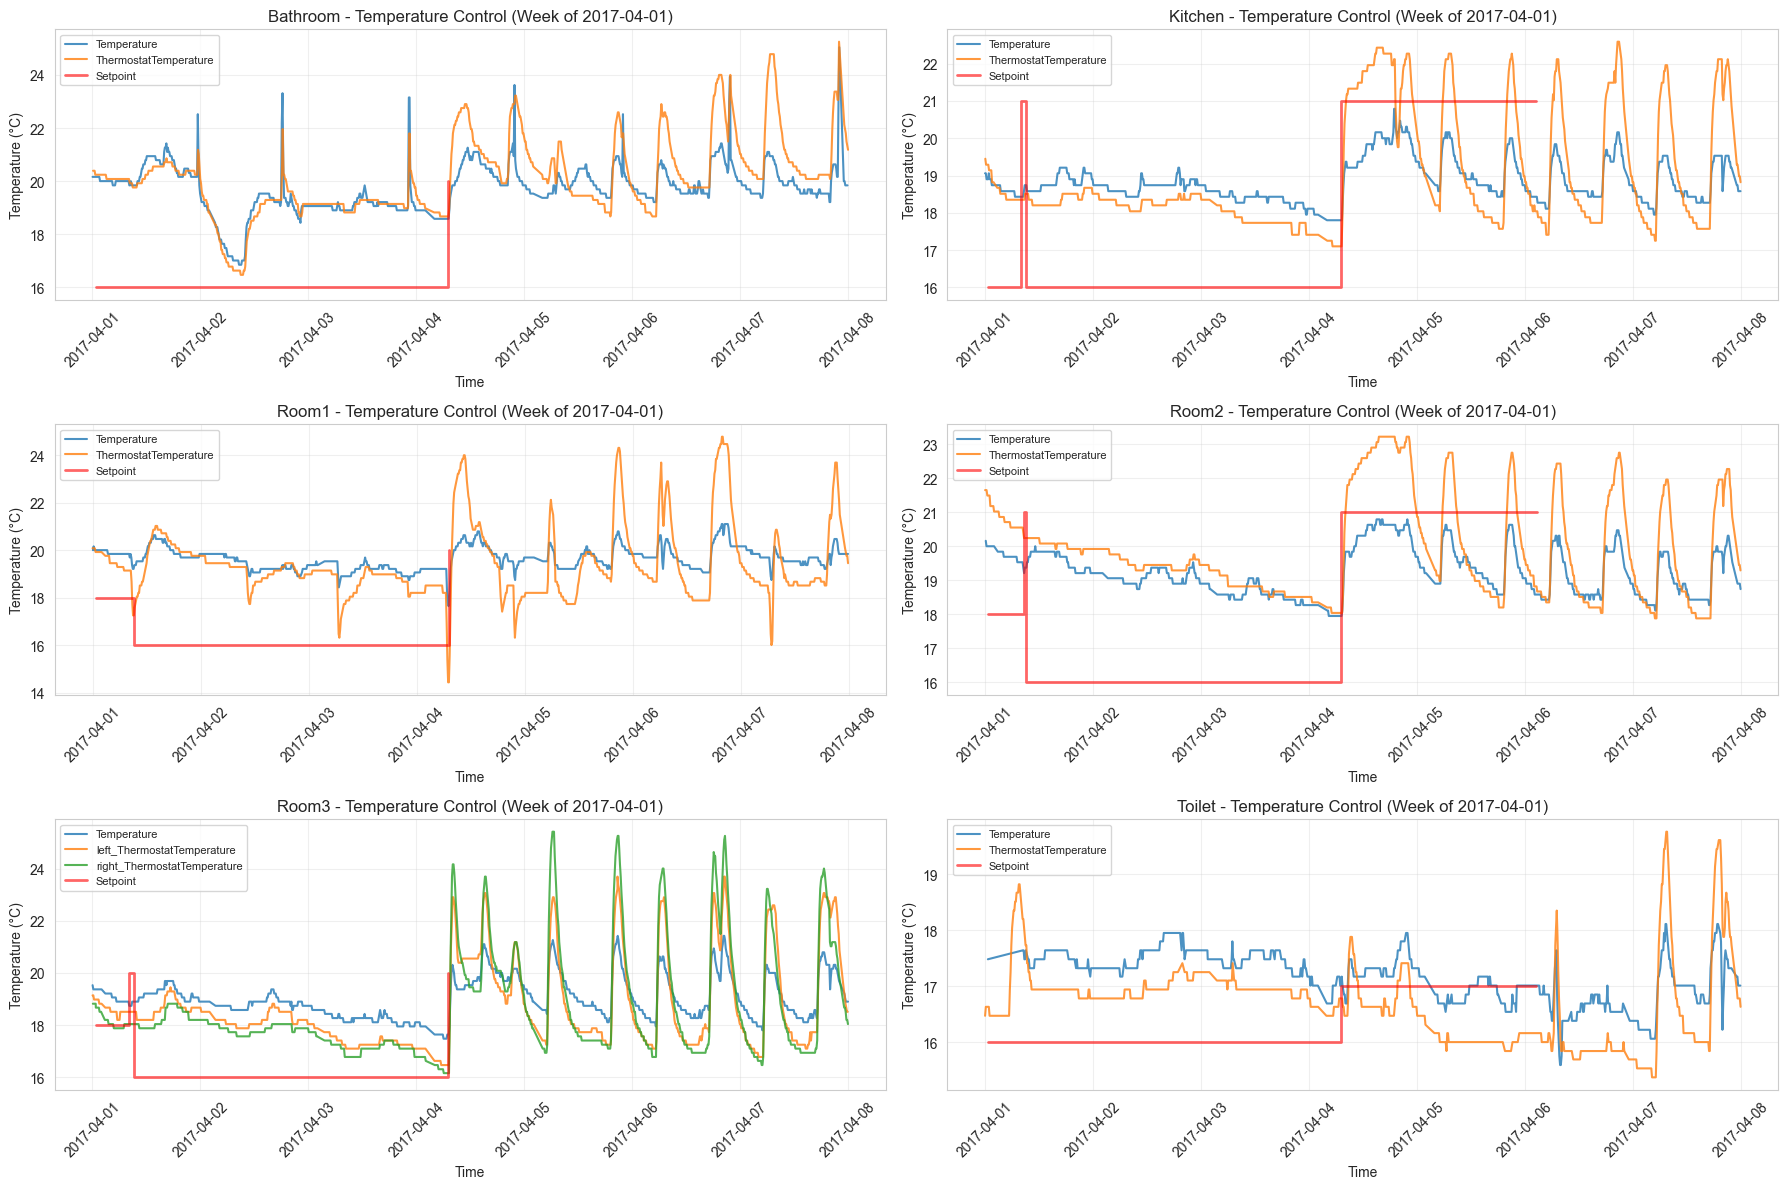

In [8]:
# Temporal patterns: sample one week of data from each room
print(" Visualizing sensor patterns (one week sample per room)...\n")

# Select one week in April (mid-dataset)
start_date = pd.Timestamp('2017-04-01')
end_date = start_date + timedelta(days=7)

df_week = df_all[(df_all['timestamp'] >= start_date) & (df_all['timestamp'] < end_date)]

# Plot temperature patterns for each room
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, room in enumerate(sorted(df_week['room'].unique())):
    ax = axes[idx]
    room_data = df_week[df_week['room'] == room]
    
    # Plot temperature and thermostat temperature
    for sensor_type in ['Temperature', 'ThermostatTemperature', 'left_ThermostatTemperature', 'right_ThermostatTemperature']:
        sensor_data = room_data[room_data['sensor_type'] == sensor_type]
        if len(sensor_data) > 0:
            ax.plot(sensor_data['timestamp'], sensor_data['value'], 
                   label=sensor_type, linewidth=1.5, alpha=0.8)
    
    # Plot setpoint
    setpoint_data = room_data[room_data['sensor_type'] == 'SetpointHistory']
    if len(setpoint_data) > 0:
        ax.step(setpoint_data['timestamp'], setpoint_data['value'], 
               label='Setpoint', linewidth=2, color='red', alpha=0.6, where='post')
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Temperature (°C)')
    ax.set_title(f'{room} - Temperature Control (Week of {start_date.date()})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [9]:
# Analyze sampling intervals
print("⏱  Sampling Interval Analysis\n")

sampling_stats = []

for sensor_id in df_all['sensor_id'].unique():
    sensor_df = df_all[df_all['sensor_id'] == sensor_id].sort_values('timestamp')
    
    if len(sensor_df) < 2:
        continue
    
    intervals = sensor_df['timestamp'].diff().dt.total_seconds().dropna()
    
    sampling_stats.append({
        'sensor_id': sensor_id,
        'room': sensor_df['room'].iloc[0],
        'sensor_type': sensor_df['sensor_type'].iloc[0],
        'readings': len(sensor_df),
        'median_interval': intervals.median(),
        'mean_interval': intervals.mean(),
        'std_interval': intervals.std(),
        'min_interval': intervals.min(),
        'max_interval': intervals.max()
    })

sampling_df = pd.DataFrame(sampling_stats)
sampling_df = sampling_df.sort_values('median_interval')

print("Sampling characteristics (sorted by median interval):\n")
print(sampling_df[['sensor_id', 'readings', 'median_interval', 'std_interval', 'min_interval', 'max_interval']].to_string())

print(f"\n Summary by sensor type:")
print(sampling_df.groupby('sensor_type')[['median_interval', 'mean_interval', 'std_interval']].mean())

⏱️  Sampling Interval Analysis

Sampling characteristics (sorted by median interval):

                              sensor_id  readings  median_interval  std_interval  min_interval  max_interval
0                      Room3_Brightness     11086            607.0   1666.719787          45.0       78878.0
21                    Room3_Temperature     10968            607.0   1103.879264          45.0       78878.0
8                   Bathroom_Brightness     11248            607.0   1515.316036          47.0       79093.0
35                   Kitchen_Brightness     10878            607.0   1618.779218          48.0       79458.0
30                     Kitchen_Humidity     10104            608.0   1463.874541          54.0       79458.0
29                  Kitchen_Temperature     10435            608.0   1177.067900          48.0       79458.0
28                       Room1_Humidity     10329            608.0   1355.698801          53.0       79275.0
27                      Toilet_Humidity  

## 3. Data Quality Detection

We analyze the smart home sensor data for quality issues including:
- **Missing values**: Gaps in time series
- **Sensor noise**: Statistical outliers and fluctuations
- **Drift**: Gradual calibration offset (comparing wall temp vs thermostat temp)
- **Irregular sampling**: Excessive gaps beyond typical event-driven patterns
- **Cross-sensor validation**: Physical plausibility checks

**Important**: Quality issues are tracked at the **timestamp level** for each sensor reading.

In [10]:
# Initialize quality issue tracking
quality_issues = []
quality_flags_df = df_all.copy()

# Add quality flag column
quality_flags_df['quality_flag'] = False

print(" Quality tracking initialized")
print(f"  Tracking {len(quality_flags_df):,} sensor readings")
print(f"  Monitoring {quality_flags_df['sensor_id'].nunique()} sensor streams")

✓ Quality tracking initialized
  Tracking 285,954 sensor readings
  Monitoring 37 sensor streams


In [11]:
def detect_missing_values(df, quality_flags_df):
    """Detect missing or NaN values in sensor readings"""
    issues = []
    
    # Check for NaN values
    missing_mask = df['value'].isnull()
    missing_count = missing_mask.sum()
    
    if missing_count > 0:
        # Mark missing values in quality flags
        quality_flags_df.loc[missing_mask, 'quality_flag'] = True
        
        issues.append({
            'type': 'missing_value',
            'count': int(missing_count),
            'percentage': missing_count / len(df) * 100,
            'affected_sensors': df[missing_mask]['sensor_id'].unique().tolist()
        })
    
    return issues

def detect_sensor_noise(df, quality_flags_df, z_threshold=3.0):
    """Detect statistical outliers using z-score per sensor"""
    issues = []
    
    for sensor_id in df['sensor_id'].unique():
        sensor_df = df[df['sensor_id'] == sensor_id]
        values = sensor_df['value'].dropna()
        
        if len(values) > 10:  # Need sufficient data
            # Calculate z-scores
            z_scores = np.abs(stats.zscore(values))
            outlier_mask = z_scores > z_threshold
            
            outliers = np.sum(outlier_mask)
            if outliers > 0:
                # Mark outliers in quality flags
                outlier_indices = values[outlier_mask].index
                quality_flags_df.loc[outlier_indices, 'quality_flag'] = True
                
                issues.append({
                    'type': 'sensor_noise',
                    'sensor_id': sensor_id,
                    'room': sensor_df['room'].iloc[0],
                    'sensor_type': sensor_df['sensor_type'].iloc[0],
                    'outlier_count': int(outliers),
                    'percentage': outliers / len(values) * 100,
                    'mean': float(values.mean()),
                    'std': float(values.std())
                })
    
    return issues

def detect_temperature_drift(df, quality_flags_df):
    """Detect drift by comparing wall temperature vs thermostat temperature"""
    issues = []
    
    # Check each room
    for room in df['room'].unique():
        room_data = df[df['room'] == room]
        
        # Get temperature sensors
        temp_data = room_data[room_data['sensor_type'] == 'Temperature'].copy()
        thermostat_data = room_data[room_data['sensor_type'].str.contains('ThermostatTemperature', na=False)].copy()
        
        if len(temp_data) == 0 or len(thermostat_data) == 0:
            continue
        
        # Resample to daily averages for drift detection
        temp_daily = temp_data.set_index('timestamp').resample('1D')['value'].mean()
        thermostat_daily = thermostat_data.set_index('timestamp').resample('1D')['value'].mean()
        
        # Align dates
        common_dates = temp_daily.index.intersection(thermostat_daily.index)
        if len(common_dates) < 7:  # Need at least a week
            continue
        
        temp_daily = temp_daily[common_dates]
        thermostat_daily = thermostat_daily[common_dates]
        
        # Calculate difference trend
        diff = temp_daily - thermostat_daily
        
        # Check for systematic drift (trend over time)
        if len(diff) > 14:  # Need sufficient data points
            # Linear regression to detect drift
            x = np.arange(len(diff))
            slope, intercept = np.polyfit(x, diff.values, 1)
            
            # Check if drift is significant (>0.1°C over the period)
            total_drift = slope * len(diff)
            
            if abs(total_drift) > 0.5:  # Significant drift threshold
                issues.append({
                    'type': 'temperature_drift',
                    'room': room,
                    'drift_magnitude': float(total_drift),
                    'drift_rate': float(slope),
                    'days': len(diff),
                    'description': f'Drift of {total_drift:.2f}°C over {len(diff)} days'
                })
    
    return issues

def detect_excessive_sampling_gaps(df, quality_flags_df):
    """Detect sampling gaps beyond typical irregular patterns"""
    issues = []
    
    for sensor_id in df['sensor_id'].unique():
        sensor_df = df[df['sensor_id'] == sensor_id].sort_values('timestamp')
        
        if len(sensor_df) < 10:
            continue
        
        # Calculate intervals
        intervals = sensor_df['timestamp'].diff().dt.total_seconds().dropna()
        
        if len(intervals) == 0:
            continue
        
        median_interval = intervals.median()
        
        # Find gaps larger than 20x median (excessive for event-driven sampling)
        large_gaps = intervals[intervals > median_interval * 20]
        
        if len(large_gaps) > len(intervals) * 0.05:  # >5% excessive gaps
            issues.append({
                'type': 'sampling_gap',
                'sensor_id': sensor_id,
                'room': sensor_df['room'].iloc[0],
                'sensor_type': sensor_df['sensor_type'].iloc[0],
                'gap_count': int(len(large_gaps)),
                'percentage': len(large_gaps) / len(intervals) * 100,
                'max_gap_hours': float(large_gaps.max() / 3600),
                'median_interval_seconds': float(median_interval)
            })
    
    return issues

def detect_stuck_sensor(df, quality_flags_df):
    """Detect sensors reporting constant values (stuck)"""
    issues = []
    
    for sensor_id in df['sensor_id'].unique():
        sensor_df = df[df['sensor_id'] == sensor_id].sort_values('timestamp')
        
        if len(sensor_df) < 100:  # Need sufficient data
            continue
        
        # Skip setpoint sensors (expected to be constant for long periods)
        if 'Setpoint' in sensor_id:
            continue
        
        # Check for consecutive constant values
        values = sensor_df['value'].values
        constant_runs = []
        current_run = 1
        
        for i in range(1, len(values)):
            if values[i] == values[i-1]:
                current_run += 1
            else:
                if current_run > 50:  # More than 50 consecutive identical readings
                    constant_runs.append(current_run)
                current_run = 1
        
        if len(constant_runs) > 0:
            max_run = max(constant_runs)
            if max_run > 100:  # Significant stuck period
                issues.append({
                    'type': 'stuck_sensor',
                    'sensor_id': sensor_id,
                    'room': sensor_df['room'].iloc[0],
                    'sensor_type': sensor_df['sensor_type'].iloc[0],
                    'max_constant_readings': int(max_run),
                    'constant_periods': len(constant_runs),
                    'stuck_value': float(values[0])  # First value in sequence
                })
    
    return issues

print(" Quality detection functions defined")
print("  • detect_missing_values: Check for NaN/null values")
print("  • detect_sensor_noise: Z-score outlier detection per sensor")
print("  • detect_temperature_drift: Compare wall vs thermostat temp")
print("  • detect_excessive_sampling_gaps: Irregular sampling beyond normal")
print("  • detect_stuck_sensor: Constant value detection")

✓ Quality detection functions defined
  • detect_missing_values: Check for NaN/null values
  • detect_sensor_noise: Z-score outlier detection per sensor
  • detect_temperature_drift: Compare wall vs thermostat temp
  • detect_excessive_sampling_gaps: Irregular sampling beyond normal
  • detect_stuck_sensor: Constant value detection


In [12]:
# Run quality detection
print(" Running data quality detection...\\n")

# 1. Detect missing values
missing_issues = detect_missing_values(df_all, quality_flags_df)
quality_issues.extend(missing_issues)
print(f" Missing value detection: {len(missing_issues)} issues found")

# 2. Detect sensor noise/outliers
noise_issues = detect_sensor_noise(df_all, quality_flags_df, z_threshold=3.0)
quality_issues.extend(noise_issues)
print(f" Sensor noise detection: {len(noise_issues)} sensors with outliers")

# 3. Detect temperature drift
drift_issues = detect_temperature_drift(df_all, quality_flags_df)
quality_issues.extend(drift_issues)
print(f" Temperature drift detection: {len(drift_issues)} rooms with drift")

# 4. Detect sampling gaps
gap_issues = detect_excessive_sampling_gaps(df_all, quality_flags_df)
quality_issues.extend(gap_issues)
print(f" Sampling gap detection: {len(gap_issues)} sensors with excessive gaps")

# 5. Detect stuck sensors
stuck_issues = detect_stuck_sensor(df_all, quality_flags_df)
quality_issues.extend(stuck_issues)
print(f" Stuck sensor detection: {len(stuck_issues)} potentially stuck sensors")

print(f"\\n Total quality issues detected: {len(quality_issues)}")
print(f" Flagged readings: {quality_flags_df['quality_flag'].sum():,} / {len(quality_flags_df):,} ({quality_flags_df['quality_flag'].sum()/len(quality_flags_df)*100:.2f}%)")

🔍 Running data quality detection...\n
✓ Missing value detection: 0 issues found
✓ Sensor noise detection: 28 sensors with outliers
✓ Temperature drift detection: 4 rooms with drift
✓ Sensor noise detection: 28 sensors with outliers
✓ Temperature drift detection: 4 rooms with drift
✓ Sampling gap detection: 0 sensors with excessive gaps
✓ Sampling gap detection: 0 sensors with excessive gaps
✓ Stuck sensor detection: 10 potentially stuck sensors
\n📋 Total quality issues detected: 42
📍 Flagged readings: 2,497 / 285,954 (0.87%)
✓ Stuck sensor detection: 10 potentially stuck sensors
\n📋 Total quality issues detected: 42
📍 Flagged readings: 2,497 / 285,954 (0.87%)


In [14]:
# Display quality issues summary
if len(quality_issues) > 0:
    quality_df = pd.DataFrame(quality_issues)
    print("\\n  Data Quality Issues Summary:\\n")
    
    # Group by issue type
    print("Issues by type:")
    print(quality_df['type'].value_counts())
    
    print("\\n" + "="*80)
    print("Detailed Quality Issues:")
    print("="*80)
    
    # Show noise issues
    noise_df = quality_df[quality_df['type'] == 'sensor_noise']
    if len(noise_df) > 0:
        print(f"\\n SENSOR NOISE ({len(noise_df)} sensors):")
        for _, issue in noise_df.iterrows():
            print(f"  • {issue['sensor_id']:50s} {int(issue['outlier_count']):4d} outliers ({issue['percentage']:.1f}%)")
    
    # Show drift issues
    drift_df = quality_df[quality_df['type'] == 'temperature_drift']
    if len(drift_df) > 0:
        print(f"\\n TEMPERATURE DRIFT ({len(drift_df)} rooms):")
        for _, issue in drift_df.iterrows():
            print(f"  • {issue['room']:15s} {issue['description']}")
    
    # Show gap issues
    gap_df = quality_df[quality_df['type'] == 'sampling_gap']
    if len(gap_df) > 0:
        print(f"\\n⏱  SAMPLING GAPS ({len(gap_df)} sensors):")
        for _, issue in gap_df.head(10).iterrows():
            print(f"  • {issue['sensor_id']:50s} {int(issue['gap_count']):3d} gaps ({issue['percentage']:.1f}%), max: {issue['max_gap_hours']:.1f}h")
        if len(gap_df) > 10:
            print(f"  ... and {len(gap_df) - 10} more")
    
    # Show stuck sensors
    stuck_df = quality_df[quality_df['type'] == 'stuck_sensor']
    if len(stuck_df) > 0:
        print(f"\\n STUCK SENSORS ({len(stuck_df)} sensors):")
        for _, issue in stuck_df.iterrows():
            print(f"  • {issue['sensor_id']:50s} {int(issue['max_constant_readings']):4d} constant readings")
    
else:
    print(" No major quality issues detected")

\n⚠️  Data Quality Issues Summary:\n
Issues by type:
type
sensor_noise         28
stuck_sensor         10
temperature_drift     4
Name: count, dtype: int64
\n================================================================================
Detailed Quality Issues:
\n🔊 SENSOR NOISE (28 sensors):
  • Room3_Brightness                                    404 outliers (3.6%)
  • Kitchen_Virtual_OutdoorTemperature                    2 outliers (0.1%)
  • Bathroom_Virtual_OutdoorTemperature                   2 outliers (0.1%)
  • Room1_Virtual_OutdoorTemperature                      2 outliers (0.1%)
  • Room2_OutdoorTemperature                              2 outliers (0.1%)
  • Room3_Virtual_OutdoorTemperature                      2 outliers (0.1%)
  • Toilet_Virtual_OutdoorTemperature                     2 outliers (0.1%)
  • Bathroom_ThermostatTemperature                      266 outliers (2.4%)
  • Bathroom_Brightness                                 347 outliers (3.1%)
  • Bathroom_Temperat

## 4. Event Abstraction

Transform raw sensor patterns into **smart home process events** based on the domain context:

**Dataset Context**:
- Smart home flat in Nuremberg, Germany (March-June 2017)
- 6 rooms with individual heating control (thermostatic radiator valves)
- Daily living patterns: cooking, bathing, sleeping, occupancy
- HVAC process: schedule-based setpoints, automated temperature control

**Process Model**: Daily living patterns per room
- **Heating Events**: Setpoint changes, temperature control, target reached
- **Humidity Events**: Cooking, showering, ventilation
- **Occupancy Events**: Light patterns, activity detection
- **Room-Specific Patterns**: Kitchen cooking, bathroom showering, bedroom sleeping

**Quality Propagation**: Sensor quality flags propagate to events detected in affected time windows.

In [15]:
# Calculate context-aware thresholds from sensor distributions
print(" Calculating context-aware thresholds from sensor distributions...\n")
print("Context: Smart Home in Nuremberg, Germany (March-June 2017)")
print("  - 6 rooms with individual HVAC control")
print("  - Daily living patterns: cooking, bathing, occupancy")
print("  - Season: Late winter → late spring (heating season)\n")

# Calculate thresholds for each sensor type
THRESHOLDS = {}

# Temperature thresholds (comfort zones)
temp_data = df_all[df_all['sensor_type'].str.contains('Temperature', na=False)]['value']
THRESHOLDS['temperature'] = {
    'cold': 18.0,      # Economy/night mode
    'comfort': 20.0,   # Standard comfort
    'warm': 22.0       # High comfort
}

# Humidity thresholds (indoor air quality)
humid_data = df_all[df_all['sensor_type'] == 'Humidity']['value']
THRESHOLDS['humidity'] = {
    'low': 30.0,       # Dry air
    'comfortable': 50.0,  # Ideal range
    'high': 60.0,      # Risk of mold
    'spike_threshold': 10.0  # Change in 15 min for event detection
}

# Brightness thresholds (occupancy detection)
bright_data = df_all[df_all['sensor_type'] == 'Brightness']['value']
THRESHOLDS['brightness'] = {
    'dark': 5.0,       # Unoccupied/night
    'dim': 50.0,       # Low lighting
    'bright': 200.0    # Active occupancy
}

print(" Event detection thresholds calculated")
print("\nContext-Aware Thresholds:")
print(f"  Temperature:")
print(f"    - Cold/Economy: {THRESHOLDS['temperature']['cold']:.1f}°C")
print(f"    - Comfort: {THRESHOLDS['temperature']['comfort']:.1f}°C")
print(f"    - Warm: {THRESHOLDS['temperature']['warm']:.1f}°C")
print(f"  Humidity:")
print(f"    - Low: {THRESHOLDS['humidity']['low']:.1f}%")
print(f"    - Comfortable: {THRESHOLDS['humidity']['comfortable']:.1f}%")
print(f"    - High: {THRESHOLDS['humidity']['high']:.1f}%")
print(f"  Brightness:")
print(f"    - Dark: {THRESHOLDS['brightness']['dark']:.1f} lux")
print(f"    - Dim: {THRESHOLDS['brightness']['dim']:.1f} lux")
print(f"    - Bright: {THRESHOLDS['brightness']['bright']:.1f} lux")

📊 Calculating context-aware thresholds from sensor distributions...

Context: Smart Home in Nuremberg, Germany (March-June 2017)
  - 6 rooms with individual HVAC control
  - Daily living patterns: cooking, bathing, occupancy
  - Season: Late winter → late spring (heating season)

✓ Event detection thresholds calculated

Context-Aware Thresholds:
  Temperature:
    - Cold/Economy: 18.0°C
    - Comfort: 20.0°C
    - Warm: 22.0°C
  Humidity:
    - Low: 30.0%
    - Comfortable: 50.0%
    - High: 60.0%
  Brightness:
    - Dark: 5.0 lux
    - Dim: 50.0 lux
    - Bright: 200.0 lux


In [16]:
def abstract_events_from_sensors(df, quality_flags_df, sample_days=14):
    """
    Abstract events from sensor readings modeling smart home daily living patterns.
    Context: Smart home with 6 rooms, HVAC control, daily routines (cooking, bathing, sleeping)
    Process: Daily living patterns per room with heating, humidity, and occupancy events
    """
    events = []
    
    # Work with first N days
    start_date = df['timestamp'].min()
    end_date = start_date + timedelta(days=sample_days)
    df_sample = df[df['timestamp'] <= end_date].copy()
    
    print(f"Processing {len(df_sample):,} readings from {sample_days} days...")
    print(f"Modeling smart home processes: heating, occupancy, daily routines")
    
    # Add temporal features
    df_sample['day'] = df_sample['timestamp'].dt.date
    df_sample['hour'] = df_sample['timestamp'].dt.hour
    
    # Process each room-day combination as a case
    for room in df_sample['room'].unique():
        room_data = df_sample[df_sample['room'] == room]
        
        for day in room_data['day'].unique():
            day_data = room_data[room_data['day'] == day].copy()
            case_id = f"{room}_{day}"
            
            # Detect heating events
            heating_events = detect_heating_events(day_data, quality_flags_df, case_id, room)
            events.extend(heating_events)
            
            # Detect humidity events (cooking, showering)
            humidity_events = detect_humidity_events(day_data, quality_flags_df, case_id, room)
            events.extend(humidity_events)
            
            # Detect occupancy patterns
            occupancy_events = detect_occupancy_events(day_data, quality_flags_df, case_id, room)
            events.extend(occupancy_events)
            
            # Detect schedule changes
            schedule_events = detect_schedule_events(day_data, quality_flags_df, case_id, room)
            events.extend(schedule_events)
    
    return pd.DataFrame(events)

def detect_heating_events(day_data, quality_flags_df, case_id, room):
    """Detect heating control events: setpoint changes, heating active, target reached"""
    events = []
    
    # Get temperature and setpoint data
    temp_data = day_data[day_data['sensor_type'].str.contains('Temperature', na=False)].sort_values('timestamp')
    setpoint_data = day_data[day_data['sensor_type'] == 'SetpointHistory'].sort_values('timestamp')
    
    if len(temp_data) == 0:
        return events
    
    # Detect setpoint changes
    for idx, row in setpoint_data.iterrows():
        quality_flag = check_quality_flag(row, quality_flags_df)
        
        events.append({
            'case_id': case_id,
            'activity': 'Setpoint_Change',
            'timestamp': row['timestamp'],
            'room': room,
            'sensor': 'setpoint',
            'value': row['value'],
            'quality_flag': quality_flag
        })
    
    # Detect heating periods (temperature rising significantly)
    temp_resampled = temp_data.set_index('timestamp').resample('30T')['value'].mean()
    
    for i in range(1, len(temp_resampled)):
        if pd.notna(temp_resampled.iloc[i]) and pd.notna(temp_resampled.iloc[i-1]):
            temp_change = temp_resampled.iloc[i] - temp_resampled.iloc[i-1]
            
            if temp_change > 0.5:  # Significant heating
                timestamp = temp_resampled.index[i]
                quality_flag = check_window_quality(day_data, quality_flags_df, timestamp, timedelta(minutes=30))
                
                events.append({
                    'case_id': case_id,
                    'activity': 'Heating_Active',
                    'timestamp': timestamp,
                    'room': room,
                    'sensor': 'temperature',
                    'value': temp_resampled.iloc[i],
                    'quality_flag': quality_flag
                })
    
    return events

def detect_humidity_events(day_data, quality_flags_df, case_id, room):
    """Detect humidity events: spikes (cooking, showering), ventilation"""
    events = []
    
    humid_data = day_data[day_data['sensor_type'] == 'Humidity'].sort_values('timestamp')
    
    if len(humid_data) < 5:
        return events
    
    # Resample to 15-minute windows
    humid_resampled = humid_data.set_index('timestamp').resample('15T')['value'].mean()
    
    for i in range(1, len(humid_resampled)):
        if pd.notna(humid_resampled.iloc[i]) and pd.notna(humid_resampled.iloc[i-1]):
            humid_change = humid_resampled.iloc[i] - humid_resampled.iloc[i-1]
            timestamp = humid_resampled.index[i]
            
            # Humidity spike (cooking, showering)
            if humid_change > THRESHOLDS['humidity']['spike_threshold']:
                quality_flag = check_window_quality(day_data, quality_flags_df, timestamp, timedelta(minutes=15))
                
                # Determine activity type based on room
                if room == 'Bathroom':
                    activity = 'Shower_Event'
                elif room == 'Kitchen':
                    activity = 'Cooking_Event'
                else:
                    activity = 'Humidity_Spike'
                
                events.append({
                    'case_id': case_id,
                    'activity': activity,
                    'timestamp': timestamp,
                    'room': room,
                    'sensor': 'humidity',
                    'value': humid_resampled.iloc[i],
                    'quality_flag': quality_flag
                })
            
            # Ventilation (rapid humidity decrease)
            elif humid_change < -THRESHOLDS['humidity']['spike_threshold']:
                quality_flag = check_window_quality(day_data, quality_flags_df, timestamp, timedelta(minutes=15))
                
                events.append({
                    'case_id': case_id,
                    'activity': 'Ventilation',
                    'timestamp': timestamp,
                    'room': room,
                    'sensor': 'humidity',
                    'value': humid_resampled.iloc[i],
                    'quality_flag': quality_flag
                })
    
    return events

def detect_occupancy_events(day_data, quality_flags_df, case_id, room):
    """Detect occupancy based on brightness patterns"""
    events = []
    
    bright_data = day_data[day_data['sensor_type'] == 'Brightness'].sort_values('timestamp')
    
    if len(bright_data) < 5:
        return events
    
    # Resample to 30-minute windows
    bright_resampled = bright_data.set_index('timestamp').resample('30T')['value'].mean()
    
    prev_state = None
    for i in range(len(bright_resampled)):
        if pd.notna(bright_resampled.iloc[i]):
            value = bright_resampled.iloc[i]
            timestamp = bright_resampled.index[i]
            
            # Determine state
            if value > THRESHOLDS['brightness']['bright']:
                state = 'High_Occupancy'
            elif value > THRESHOLDS['brightness']['dim']:
                state = 'Low_Occupancy'
            else:
                state = 'Unoccupied'
            
            # Only log state changes
            if state != prev_state and prev_state is not None:
                quality_flag = check_window_quality(day_data, quality_flags_df, timestamp, timedelta(minutes=30))
                
                events.append({
                    'case_id': case_id,
                    'activity': state,
                    'timestamp': timestamp,
                    'room': room,
                    'sensor': 'brightness',
                    'value': value,
                    'quality_flag': quality_flag
                })
            
            prev_state = state
    
    return events

def detect_schedule_events(day_data, quality_flags_df, case_id, room):
    """Detect comfort mode changes based on setpoints"""
    events = []
    
    setpoint_data = day_data[day_data['sensor_type'] == 'SetpointHistory'].sort_values('timestamp')
    
    for idx, row in setpoint_data.iterrows():
        value = row['value']
        timestamp = row['timestamp']
        quality_flag = check_quality_flag(row, quality_flags_df)
        
        # Classify setpoint
        if value >= THRESHOLDS['temperature']['warm']:
            mode = 'Comfort_Mode_High'
        elif value >= THRESHOLDS['temperature']['comfort']:
            mode = 'Comfort_Mode'
        elif value >= THRESHOLDS['temperature']['cold']:
            mode = 'Economy_Mode'
        else:
            mode = 'Night_Mode'
        
        events.append({
            'case_id': case_id,
            'activity': mode,
            'timestamp': timestamp,
            'room': room,
            'sensor': 'setpoint',
            'value': value,
            'quality_flag': quality_flag
        })
    
    return events

def check_quality_flag(row, quality_flags_df):
    """Check if a specific reading has quality flag"""
    if row.name in quality_flags_df.index:
        return bool(quality_flags_df.loc[row.name, 'quality_flag'])
    return False

def check_window_quality(day_data, quality_flags_df, timestamp, window):
    """Check if any readings in time window have quality flags"""
    window_start = timestamp - window
    window_end = timestamp + window
    
    window_data = day_data[
        (day_data['timestamp'] >= window_start) & 
        (day_data['timestamp'] <= window_end)
    ]
    
    for idx in window_data.index:
        if idx in quality_flags_df.index:
            if quality_flags_df.loc[idx, 'quality_flag']:
                return True
    
    return False

print(" Event abstraction functions defined")
print("  • abstract_events_from_sensors: Main orchestrator")
print("  • detect_heating_events: Setpoint changes, heating active")
print("  • detect_humidity_events: Cooking, showering, ventilation")
print("  • detect_occupancy_events: Room occupancy based on brightness")
print("  • detect_schedule_events: Comfort mode classification")

✓ Event abstraction functions defined
  • abstract_events_from_sensors: Main orchestrator
  • detect_heating_events: Setpoint changes, heating active
  • detect_humidity_events: Cooking, showering, ventilation
  • detect_occupancy_events: Room occupancy based on brightness
  • detect_schedule_events: Comfort mode classification


In [17]:
# Abstract events from sensor data
print(" Abstracting events from sensor patterns...\n")

event_log = abstract_events_from_sensors(df_all, quality_flags_df, sample_days=14)

# Rename to pm4py standard format
event_log = event_log.rename(columns={
    'case_id': 'case:concept:name',
    'activity': 'concept:name',
    'timestamp': 'time:timestamp'
})

event_log = event_log.sort_values(['case:concept:name', 'time:timestamp']).reset_index(drop=True)

print(f"\n Event abstraction complete!")
print(f"\n Event Log Statistics:")
print(f"  Total events: {len(event_log):,}")
print(f"  Total cases: {event_log['case:concept:name'].nunique()}")
print(f"  Unique activities: {event_log['concept:name'].nunique()}")
print(f"  Events with quality flags: {event_log['quality_flag'].sum():,}")
print(f"  Quality flag percentage: {event_log['quality_flag'].sum() / len(event_log) * 100:.1f}%")

print(f"\n Activity distribution:")
print(event_log['concept:name'].value_counts())

print(f"\n Cases by room:")
room_cases = event_log['case:concept:name'].apply(lambda x: x.split('_')[0]).value_counts()
print(room_cases)

🔄 Abstracting events from sensor patterns...

Processing 20,175 readings from 14 days...
Modeling smart home processes: heating, occupancy, daily routines

✅ Event abstraction complete!

📊 Event Log Statistics:
  Total events: 2,747
  Total cases: 84
  Unique activities: 12
  Events with quality flags: 200
  Quality flag percentage: 7.3%

📍 Activity distribution:
concept:name
Heating_Active       1452
Setpoint_Change       426
Night_Mode            230
Low_Occupancy         201
Comfort_Mode          148
Unoccupied            118
High_Occupancy         94
Economy_Mode           45
Ventilation            21
Shower_Event            8
Comfort_Mode_High       3
Cooking_Event           1
Name: count, dtype: int64

📍 Cases by room:
case:concept:name
Bathroom    498
Room3       466
Kitchen     454
Room1       450
Room2       441
Toilet      438
Name: count, dtype: int64

✅ Event abstraction complete!

📊 Event Log Statistics:
  Total events: 2,747
  Total cases: 84
  Unique activities: 12
  Eve

In [18]:
# Display sample event log
print("\nSample Event Log (first 20 events):\n")
event_log.head(20)


Sample Event Log (first 20 events):



,case:concept:name,concept:name,time:timestamp,room,sensor,value,quality_flag
0,Bathroom_2017-03-09,Heating_Active,2017-03-09 01:00:00,Bathroom,temperature,21.410000,False
1,Bathroom_2017-03-09,Heating_Active,2017-03-09 02:00:00,Bathroom,temperature,20.860000,False
2,Bathroom_2017-03-09,Heating_Active,2017-03-09 03:00:00,Bathroom,temperature,20.550000,False
3,Bathroom_2017-03-09,Heating_Active,2017-03-09 04:00:00,Bathroom,temperature,20.240000,False
4,Bathroom_2017-03-09,Heating_Active,2017-03-09 05:00:00,Bathroom,temperature,18.900000,False
5,Bathroom_2017-03-09,Setpoint_Change,2017-03-09 05:25:31,Bathroom,setpoint,20.000000,False
6,Bathroom_2017-03-09,Comfort_Mode,2017-03-09 05:25:31,Bathroom,setpoint,20.000000,False
7,Bathroom_2017-03-09,Heating_Active,2017-03-09 06:00:00,Bathroom,temperature,22.588000,False
8,Bathroom_2017-03-09,Heating_Active,2017-03-09 07:00:00,Bathroom,temperature,25.982500,True
9,Bathroom_2017-03-09,Setpoint_Change,2017-03-09 07:30:23,Bathroom,setpoint,16.000000,False


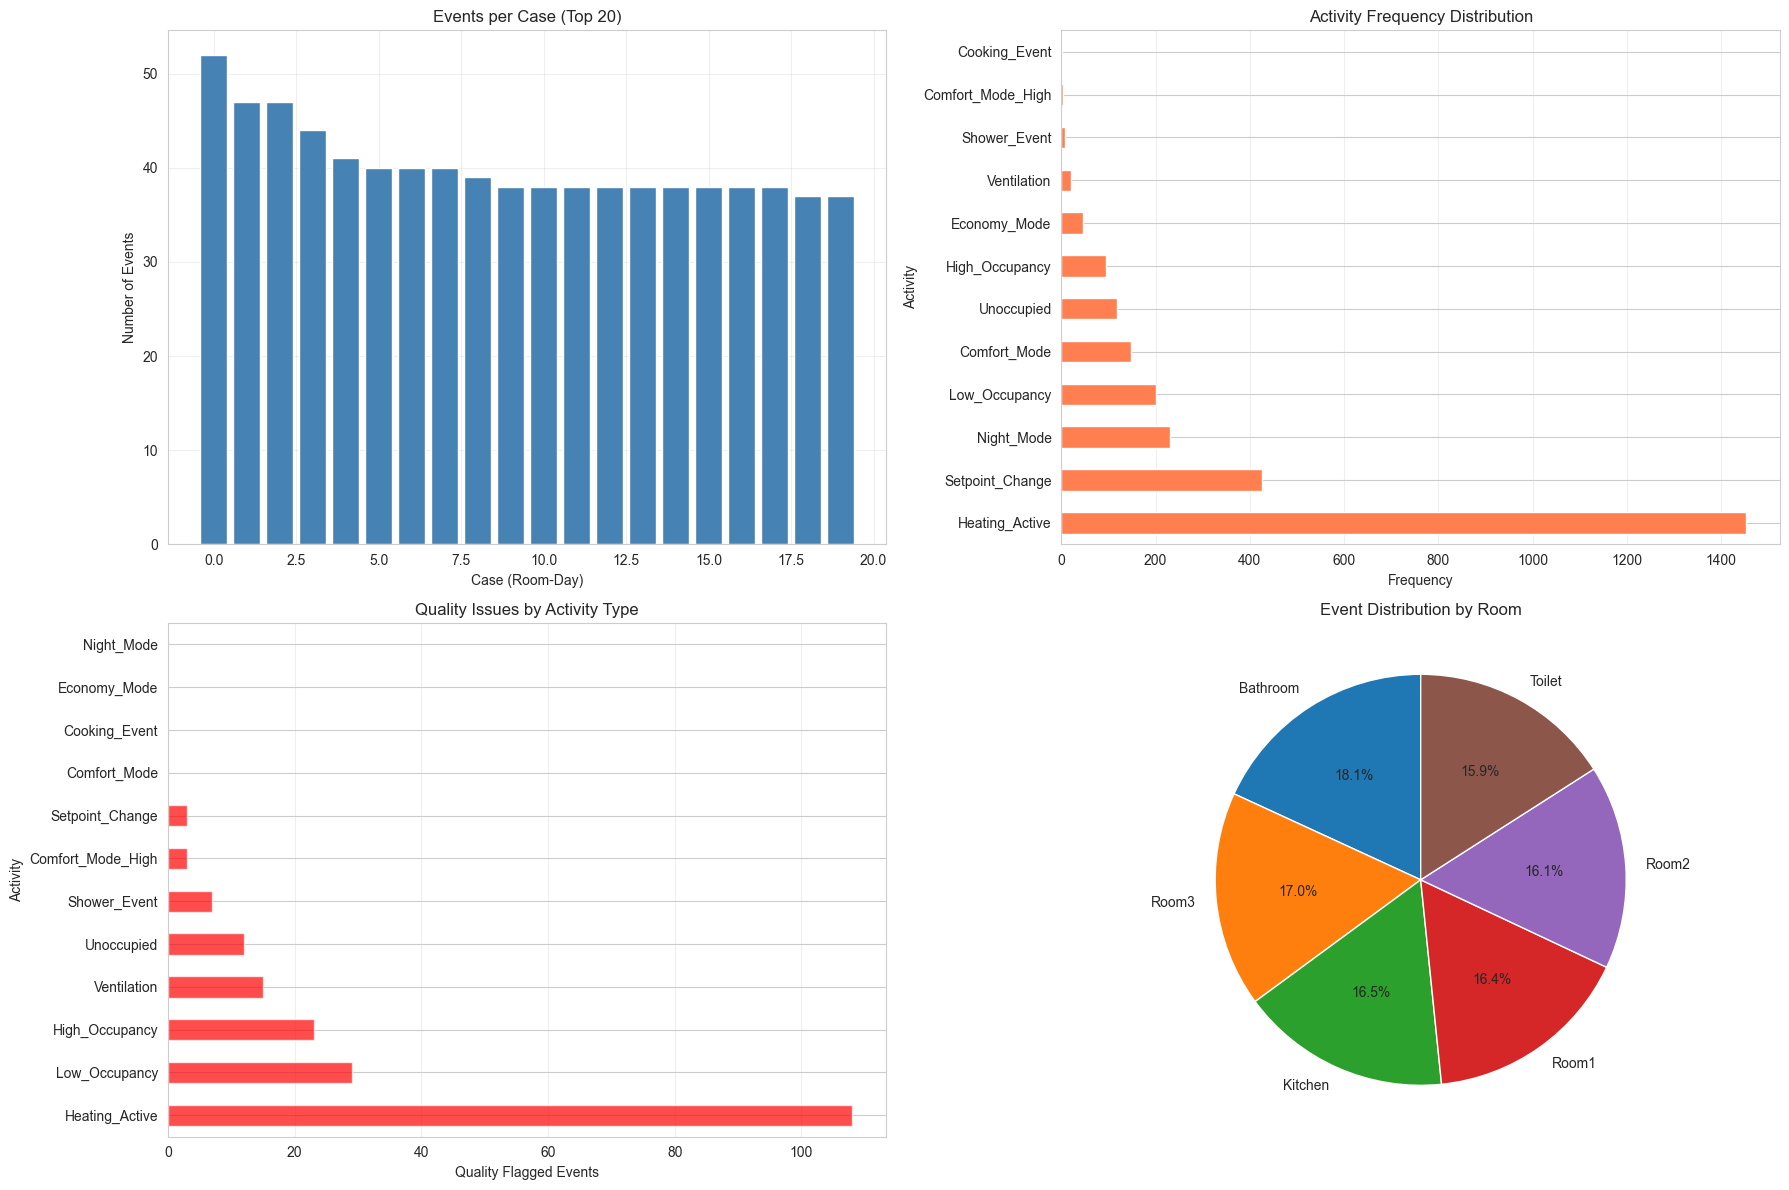

In [19]:
# Visualize event distribution
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Events per case
ax1 = axes[0, 0]
events_per_case = event_log.groupby('case:concept:name').size().sort_values(ascending=False)
top_cases = events_per_case.head(20)
ax1.bar(range(len(top_cases)), top_cases.values, color='steelblue')
ax1.set_xlabel('Case (Room-Day)')
ax1.set_ylabel('Number of Events')
ax1.set_title('Events per Case (Top 20)')
ax1.grid(True, alpha=0.3)

# Activity frequency
ax2 = axes[0, 1]
activity_counts = event_log['concept:name'].value_counts()
activity_counts.plot(kind='barh', ax=ax2, color='coral')
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Activity')
ax2.set_title('Activity Frequency Distribution')
ax2.grid(True, alpha=0.3, axis='x')

# Quality flags by activity
ax3 = axes[1, 0]
quality_by_activity = event_log.groupby('concept:name')['quality_flag'].sum().sort_values(ascending=False)
quality_by_activity.plot(kind='barh', ax=ax3, color='red', alpha=0.7)
ax3.set_xlabel('Quality Flagged Events')
ax3.set_ylabel('Activity')
ax3.set_title('Quality Issues by Activity Type')
ax3.grid(True, alpha=0.3, axis='x')

# Events by room
ax4 = axes[1, 1]
room_events = event_log['room'].value_counts()
ax4.pie(room_events.values, labels=room_events.index, autopct='%1.1f%%', startangle=90)
ax4.set_title('Event Distribution by Room')

plt.tight_layout()
plt.show()

## 5. Process Discovery & Ground Truth Selection

We use pm4py to discover the process model and select a baseline "normal" day for conformance checking.

In [20]:
# Import pm4py
import pm4py

print(" pm4py imported successfully")

✓ pm4py imported successfully


In [21]:
# Calculate case quality scores
case_stats = []

for case_id in event_log['case:concept:name'].unique():
    case_events = event_log[event_log['case:concept:name'] == case_id]
    
    case_stats.append({
        'case_id': case_id,
        'room': case_events['room'].iloc[0] if len(case_events) > 0 else None,
        'num_events': len(case_events),
        'num_quality_issues': case_events['quality_flag'].sum(),
        'quality_ratio': case_events['quality_flag'].sum() / len(case_events) if len(case_events) > 0 else 0,
        'duration': (case_events['time:timestamp'].max() - case_events['time:timestamp'].min()).total_seconds() if len(case_events) > 1 else 0,
        'unique_activities': case_events['concept:name'].nunique()
    })

case_stats_df = pd.DataFrame(case_stats)

print("Case Statistics Summary:\n")
print(case_stats_df.head(20))

print(f"\n Statistics by room:")
print(case_stats_df.groupby('room')[['num_events', 'num_quality_issues', 'quality_ratio']].mean())

Case Statistics Summary:

                case_id      room  num_events  num_quality_issues  quality_ratio  duration  unique_activities
0   Bathroom_2017-03-09  Bathroom          30                   3       0.100000   73821.0                  6
1   Bathroom_2017-03-10  Bathroom          52                  22       0.423077   73803.0                 10
2   Bathroom_2017-03-11  Bathroom          33                   6       0.181818   79200.0                  8
3   Bathroom_2017-03-12  Bathroom          28                   9       0.321429   79200.0                  8
4   Bathroom_2017-03-13  Bathroom          38                  10       0.263158   79200.0                  9
5   Bathroom_2017-03-14  Bathroom          35                   2       0.057143   79200.0                  7
6   Bathroom_2017-03-15  Bathroom          40                  10       0.250000   79200.0                  9
7   Bathroom_2017-03-16  Bathroom          37                   8       0.216216   79200.0    

In [22]:
# Select ground truth: case with typical event count and low quality issues
median_events = case_stats_df['num_events'].median()
print(f"Median events per case: {median_events:.0f}\n")

# Prioritize low quality ratio and typical event count
candidates = case_stats_df[
    (case_stats_df['num_events'] >= median_events * 0.8) &
    (case_stats_df['num_events'] <= median_events * 1.2)
].copy()

if len(candidates) > 0:
    candidates['distance_from_median'] = np.abs(candidates['num_events'] - median_events)
    candidates = candidates.sort_values(['quality_ratio', 'distance_from_median'])
    ground_truth_case = candidates.iloc[0]['case_id']
    print(f"Selected from {len(candidates)} candidates with typical event count")
else:
    # Fallback: select case with lowest quality ratio
    case_stats_df['distance_from_median'] = np.abs(case_stats_df['num_events'] - median_events)
    case_stats_df_sorted = case_stats_df.sort_values(['quality_ratio', 'distance_from_median'])
    ground_truth_case = case_stats_df_sorted.iloc[0]['case_id']
    print(f"Using fallback selection (no candidates in median range)")

ground_truth_events = event_log[event_log['case:concept:name'] == ground_truth_case].copy()

print(f"\n Selected Ground Truth Case: {ground_truth_case}")
print(f"\n   Statistics:")
gt_stats = case_stats_df[case_stats_df['case_id'] == ground_truth_case].iloc[0]
print(f"   - Room: {gt_stats['room']}")
print(f"   - Number of events: {gt_stats['num_events']}")
print(f"   - Quality issues: {gt_stats['num_quality_issues']}")
print(f"   - Quality ratio: {gt_stats['quality_ratio']:.1%}")
print(f"   - Duration: {gt_stats['duration']:.1f} seconds")
print(f"   - Unique activities: {gt_stats['unique_activities']}")

print(f"\n   Event sequence:")
for idx, row in ground_truth_events.iterrows():
    flag = "⚠️" if row['quality_flag'] else "✓"
    print(f"   {flag} {row['concept:name']}")

Median events per case: 34

Selected from 63 candidates with typical event count

🎯 Selected Ground Truth Case: Kitchen_2017-03-09

   Statistics:
   - Room: Kitchen
   - Number of events: 34
   - Quality issues: 0
   - Quality ratio: 0.0%
   - Duration: 77403.0 seconds
   - Unique activities: 7

   Event sequence:
   ✓ Setpoint_Change
   ✓ Comfort_Mode
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Low_Occupancy
   ✓ Setpoint_Change
   ✓ Night_Mode
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ High_Occupancy
   ✓ Heating_Active
   ✓ Low_Occupancy
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Setpoint_Change
   ✓ Night_Mode
   ✓ Heating_Active
   ✓ High_Occupancy
   ✓ Low_Occupancy
   ✓ Setpoint_Change
   ✓ Comfort_Mode
   ✓ Unoccupied
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Heating_Active
   ✓ Setpoint_Change
   ✓ Night_Mode


🔍 Discovering process model from ground truth case...

✅ Process model discovered!
   Places: 14
   Transitions: 16
   Arcs: 38

📊 Ground Truth Petri Net:


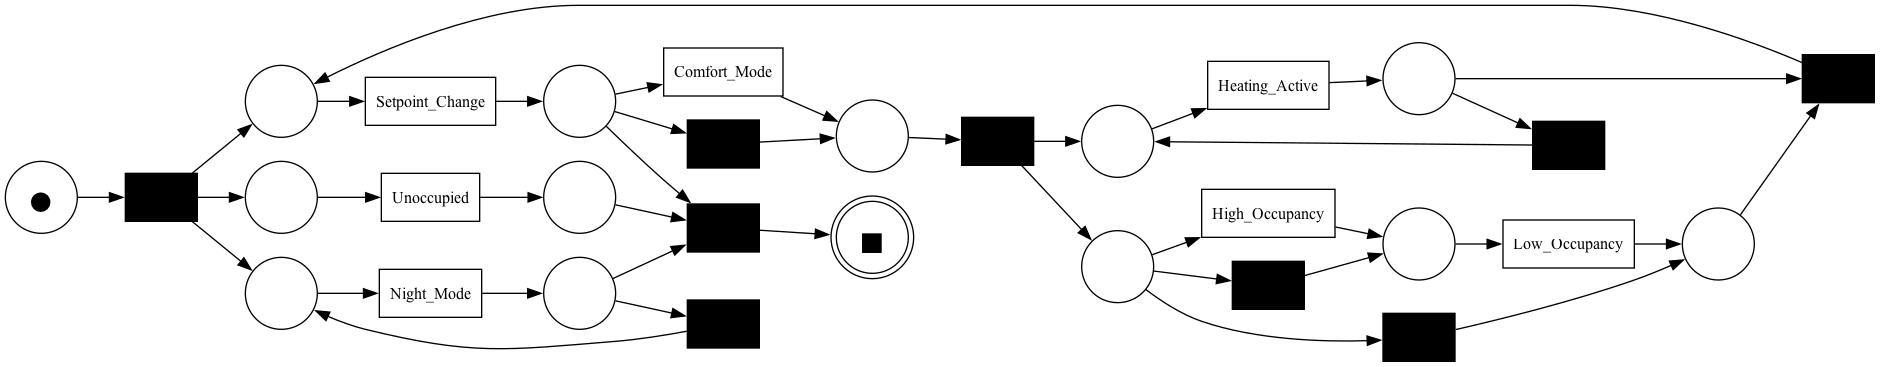

In [23]:
# Discover process model using pm4py Inductive Miner
print(" Discovering process model from ground truth case...\n")

# Create event log from ground truth case only
ground_truth_log = ground_truth_events[['case:concept:name', 'concept:name', 'time:timestamp']].copy()

# Discover Petri net using Inductive Miner
net_groundtruth, im_groundtruth, fm_groundtruth = pm4py.discover_petri_net_inductive(ground_truth_log)

print(f" Process model discovered!")
print(f"   Places: {len(net_groundtruth.places)}")
print(f"   Transitions: {len(net_groundtruth.transitions)}")
print(f"   Arcs: {len(net_groundtruth.arcs)}")

# Visualize the Petri net
print("\n Ground Truth Petri Net:")
pm4py.view_petri_net(net_groundtruth, im_groundtruth, fm_groundtruth)

# Ground truth fitness is 1.0 by definition
ground_truth_fitness = 1.0

## 6. Conformance Checking with pm4py

Compare each case against the ground truth model using token-based replay.

In [24]:
# Calculate conformance for all cases using pm4py token-based replay
print("  Calculating conformance using pm4py token-based replay...\n")

# Get fitness for all traces
fitness_results = pm4py.fitness_token_based_replay(event_log, net_groundtruth, im_groundtruth, fm_groundtruth)

print(f" Conformance checking complete!\n")
print(f" Overall Fitness Statistics:")
print(f"   Average fitness: {fitness_results['average_trace_fitness']:.3f}")
print(f"   Percentage of fitting traces: {fitness_results['percentage_of_fitting_traces']:.1f}%")
print(f"   Log fitness: {fitness_results['log_fitness']:.3f}")

# Get detailed conformance diagnostics
diagnostics = pm4py.conformance_diagnostics_token_based_replay(event_log, net_groundtruth, im_groundtruth, fm_groundtruth)

# Create conformance dataframe
case_ids = event_log['case:concept:name'].unique()
conformance_results = []

for idx, diag in enumerate(diagnostics):
    case_id = case_ids[idx]
    case_events = event_log[event_log['case:concept:name'] == case_id]
    
    conformance_results.append({
        'case_id': case_id,
        'room': case_events['room'].iloc[0] if len(case_events) > 0 else None,
        'trace_is_fit': diag['trace_is_fit'],
        'fitness': diag['trace_fitness'],
        'missing_tokens': diag['missing_tokens'],
        'consumed_tokens': diag['consumed_tokens'],
        'remaining_tokens': diag['remaining_tokens'],
        'produced_tokens': diag['produced_tokens'],
        'num_events': len(case_events),
        'quality_issues': case_events['quality_flag'].sum()
    })

conformance_df = pd.DataFrame(conformance_results)
conformance_df = conformance_df.sort_values('fitness', ascending=False)

print(f"\n Per-Case Statistics:")
print(f"   Mean fitness: {conformance_df['fitness'].mean():.3f}")
print(f"   Median fitness: {conformance_df['fitness'].median():.3f}")
print(f"   Min fitness: {conformance_df['fitness'].min():.3f}")
print(f"   Max fitness: {conformance_df['fitness'].max():.3f}")

print(f"\n   Perfect conformance cases: {len(conformance_df[conformance_df['fitness'] == 1.0])} / {len(conformance_df)}")
print(f"   Cases with fitness >= 0.8: {len(conformance_df[conformance_df['fitness'] >= 0.8])}")
print(f"   Cases with fitness < 0.5: {len(conformance_df[conformance_df['fitness'] < 0.5])}")

print(f"\n Quality Impact Analysis:")
if len(conformance_df) > 1 and conformance_df['quality_issues'].std() > 0:
    correlation = conformance_df[['quality_issues', 'fitness']].corr().iloc[0, 1]
    print(f"   Correlation (quality issues vs fitness): {correlation:.3f}")

high_quality_cases = conformance_df[conformance_df['quality_issues'] == 0]
low_quality_cases = conformance_df[conformance_df['quality_issues'] > 0]
if len(high_quality_cases) > 0:
    print(f"   Cases with NO quality issues: {len(high_quality_cases)} (avg fitness: {high_quality_cases['fitness'].mean():.3f})")
if len(low_quality_cases) > 0:
    print(f"   Cases WITH quality issues: {len(low_quality_cases)} (avg fitness: {low_quality_cases['fitness'].mean():.3f})")

⚖️  Calculating conformance using pm4py token-based replay...



replaying log with TBR, completed traces ::   0%|          | 0/84 [00:00<?, ?it/s]

✅ Conformance checking complete!

📊 Overall Fitness Statistics:
   Average fitness: 0.954
   Percentage of fitting traces: 2.4%
   Log fitness: 0.957


replaying log with TBR, completed traces ::   0%|          | 0/84 [00:00<?, ?it/s]


📊 Per-Case Statistics:
   Mean fitness: 0.954
   Median fitness: 0.960
   Min fitness: 0.877
   Max fitness: 1.000

   Perfect conformance cases: 2 / 84
   Cases with fitness >= 0.8: 84
   Cases with fitness < 0.5: 0

📍 Quality Impact Analysis:
   Correlation (quality issues vs fitness): -0.159
   Cases with NO quality issues: 48 (avg fitness: 0.956)
   Cases WITH quality issues: 36 (avg fitness: 0.952)


In [25]:
# Display conformance results
print("\nConformance Results (Top 20):\n")
conformance_df[['case_id', 'room', 'fitness', 'missing_tokens', 'consumed_tokens', 'num_events', 'quality_issues']].head(20)


Conformance Results (Top 20):



,case_id,room,fitness,missing_tokens,consumed_tokens,num_events,quality_issues
14,Kitchen_2017-03-09,Kitchen,1.000000,0,71,34,0
56,Room3_2017-03-09,Room3,1.000000,0,72,34,0
70,Toilet_2017-03-09,Toilet,0.985915,1,71,32,0
68,Room3_2017-03-21,Room3,0.985915,1,71,34,0
0,Bathroom_2017-03-09,Bathroom,0.985294,1,68,30,3
28,Room1_2017-03-09,Room1,0.985075,1,67,31,1
26,Kitchen_2017-03-21,Kitchen,0.985075,1,67,31,0
42,Room2_2017-03-09,Room2,0.985075,1,67,31,0
41,Room1_2017-03-22,Room1,0.984375,1,64,29,0
40,Room1_2017-03-21,Room1,0.983333,1,60,27,0


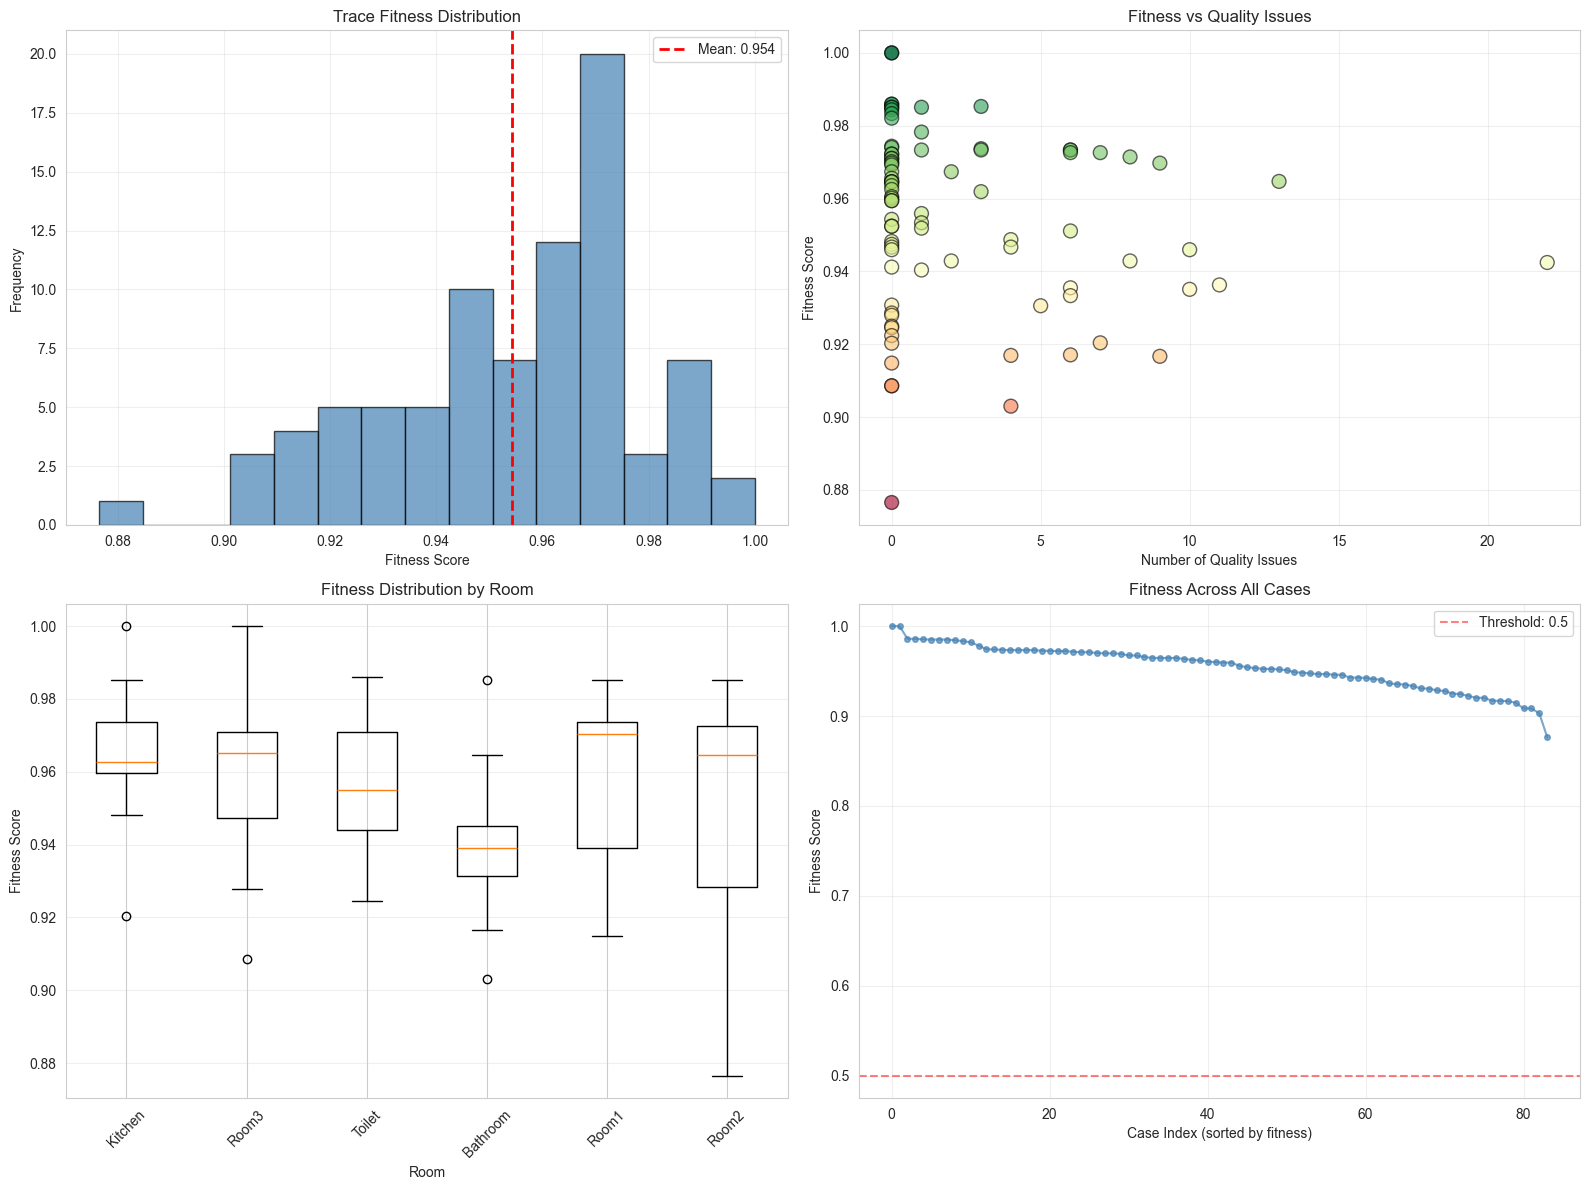

In [26]:
# Visualize conformance distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Fitness distribution
axes[0, 0].hist(conformance_df['fitness'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(conformance_df['fitness'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {conformance_df["fitness"].mean():.3f}')
axes[0, 0].set_xlabel('Fitness Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Trace Fitness Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Fitness vs Quality Issues
axes[0, 1].scatter(conformance_df['quality_issues'], conformance_df['fitness'],
                   alpha=0.6, s=100, c=conformance_df['fitness'], cmap='RdYlGn', edgecolors='black')
axes[0, 1].set_xlabel('Number of Quality Issues')
axes[0, 1].set_ylabel('Fitness Score')
axes[0, 1].set_title('Fitness vs Quality Issues')
axes[0, 1].grid(True, alpha=0.3)

# Fitness by room
axes[1, 0].boxplot([conformance_df[conformance_df['room'] == room]['fitness'].values 
                     for room in conformance_df['room'].unique()],
                    labels=conformance_df['room'].unique())
axes[1, 0].set_ylabel('Fitness Score')
axes[1, 0].set_xlabel('Room')
axes[1, 0].set_title('Fitness Distribution by Room')
axes[1, 0].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# Fitness over cases
axes[1, 1].plot(range(len(conformance_df)), conformance_df['fitness'].values,
                marker='o', linestyle='-', markersize=4, alpha=0.7, color='steelblue')
axes[1, 1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Threshold: 0.5')
axes[1, 1].set_xlabel('Case Index (sorted by fitness)')
axes[1, 1].set_ylabel('Fitness Score')
axes[1, 1].set_title('Fitness Across All Cases')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary & Results

Create a comprehensive summary of the pipeline execution.

In [27]:
# Create comprehensive pipeline summary
print("="*80)
print("OPEN SMART HOME IoT-IEQ-ENERGY DATA - PIPELINE EXECUTION SUMMARY")
print("="*80)
print()

print(f" Dataset Overview:")
print(f"   • Total sensor readings: {len(df_all):,}")
print(f"   • Sensor streams: {df_all['sensor_id'].nunique()}")
print(f"   • Rooms: {df_all['room'].nunique()} ({', '.join(sorted(df_all['room'].unique()))})")
print(f"   • Time period: {df_all['timestamp'].min()} to {df_all['timestamp'].max()}")
print(f"   • Duration: {(df_all['timestamp'].max() - df_all['timestamp'].min()).days} days")
print()

print(f" Quality Analysis:")
print(f"   • Total quality issues detected: {len(quality_issues):,}")
print(f"   • Missing values: {sum(1 for q in quality_issues if q['type'] == 'missing_value'):,}")
print(f"   • Sensor noise/outliers: {sum(1 for q in quality_issues if q['type'] == 'sensor_noise'):,}")
print(f"   • Temperature drift: {sum(1 for q in quality_issues if q['type'] == 'temperature_drift'):,}")
print(f"   • Sampling gaps: {sum(1 for q in quality_issues if q['type'] == 'sampling_gap'):,}")
print(f"   • Stuck sensors: {sum(1 for q in quality_issues if q['type'] == 'stuck_sensor'):,}")
print(f"   • Flagged readings: {quality_flags_df['quality_flag'].sum():,} ({quality_flags_df['quality_flag'].sum()/len(quality_flags_df)*100:.2f}%)")
print()

print(f" Event Abstraction:")
print(f"   • Total events generated: {len(event_log):,}")
print(f"   • Cases (room-day combinations): {event_log['case:concept:name'].nunique()}")
print(f"   • Unique activities: {event_log['concept:name'].nunique()}")
print(f"   • Activities: {', '.join(sorted(event_log['concept:name'].unique()))}")
print(f"   • Events with quality flags: {event_log['quality_flag'].sum():,} ({event_log['quality_flag'].sum()/len(event_log)*100:.1f}%)")
print()

print(f" Process Discovery:")
print(f"   • Process model: Petri Net (Inductive Miner)")
print(f"   • Places: {len(net_groundtruth.places)}")
print(f"   • Transitions: {len(net_groundtruth.transitions)}")
print(f"   • Arcs: {len(net_groundtruth.arcs)}")
print()

print(f" Conformance Checking:")
print(f"   • Ground truth case: {ground_truth_case}")
print(f"   • Average fitness: {conformance_df['fitness'].mean():.2%}")
print(f"   • Median fitness: {conformance_df['fitness'].median():.2%}")
print(f"   • Perfect conformance cases: {(conformance_df['fitness'] == 1.0).sum()}")
print(f"   • Cases analyzed: {len(conformance_df)}")
print()

print(f" Quality Impact:")
if len(conformance_df) > 1 and conformance_df['quality_issues'].std() > 0:
    correlation = conformance_df[['quality_issues', 'fitness']].corr().iloc[0, 1]
    print(f"   • Correlation (quality issues vs fitness): {correlation:.3f}")
high_quality = conformance_df[conformance_df['quality_issues'] == 0]
low_quality = conformance_df[conformance_df['quality_issues'] > 0]
if len(high_quality) > 0:
    print(f"   • Cases without quality issues: {len(high_quality)} (avg fitness: {high_quality['fitness'].mean():.3f})")
if len(low_quality) > 0:
    print(f"   • Cases with quality issues: {len(low_quality)} (avg fitness: {low_quality['fitness'].mean():.3f})")
print()

print("="*80)

OPEN SMART HOME IoT-IEQ-ENERGY DATA - PIPELINE EXECUTION SUMMARY

📊 Dataset Overview:
   • Total sensor readings: 285,954
   • Sensor streams: 37
   • Rooms: 6 (Bathroom, Kitchen, Room1, Room2, Room3, Toilet)
   • Time period: 2017-03-08 23:56:17 to 2017-06-06 04:06:22
   • Duration: 89 days

🔍 Quality Analysis:
   • Total quality issues detected: 42
   • Missing values: 0
   • Sensor noise/outliers: 28
   • Temperature drift: 4
   • Sampling gaps: 0
   • Stuck sensors: 10
   • Flagged readings: 2,497 (0.87%)

📝 Event Abstraction:
   • Total events generated: 2,747
   • Cases (room-day combinations): 84
   • Unique activities: 12
   • Activities: Comfort_Mode, Comfort_Mode_High, Cooking_Event, Economy_Mode, Heating_Active, High_Occupancy, Low_Occupancy, Night_Mode, Setpoint_Change, Shower_Event, Unoccupied, Ventilation
   • Events with quality flags: 200 (7.3%)

🔄 Process Discovery:
   • Process model: Petri Net (Inductive Miner)
   • Places: 14
   • Transitions: 16
   • Arcs: 38

✅ Co

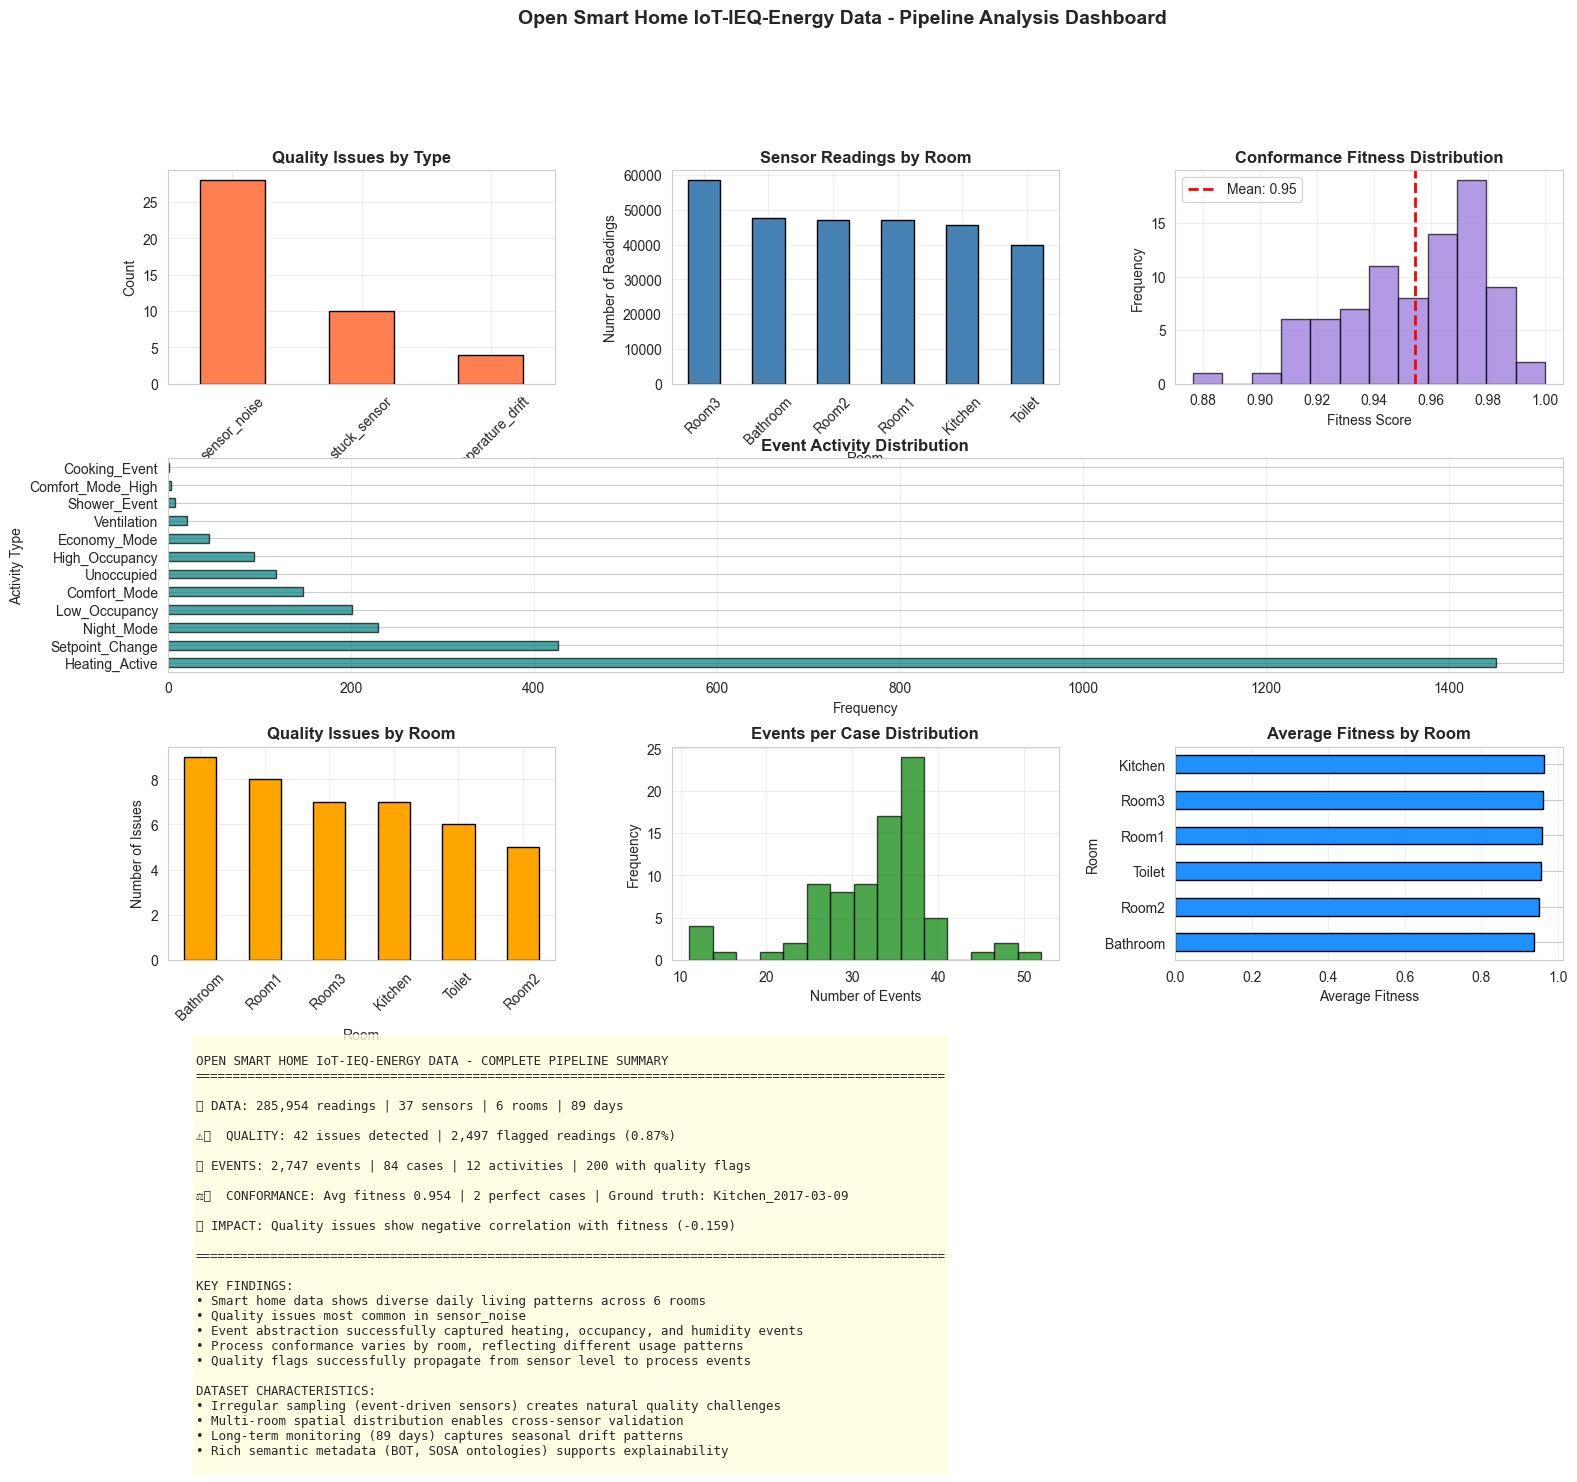

In [28]:
# Create comprehensive summary visualization
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# 1. Quality Issues Distribution
ax1 = fig.add_subplot(gs[0, 0])
if len(quality_issues) > 0:
    quality_type_counts = pd.DataFrame(quality_issues)['type'].value_counts()
    quality_type_counts.plot(kind='bar', ax=ax1, color='coral', edgecolor='black')
    ax1.set_title('Quality Issues by Type', fontweight='bold')
    ax1.set_xlabel('Issue Type')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)

# 2. Sensor Readings by Room
ax2 = fig.add_subplot(gs[0, 1])
room_readings = df_all['room'].value_counts()
room_readings.plot(kind='bar', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_title('Sensor Readings by Room', fontweight='bold')
ax2.set_xlabel('Room')
ax2.set_ylabel('Number of Readings')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Conformance Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(conformance_df['fitness'], bins=12, color='mediumpurple', edgecolor='black', alpha=0.7)
ax3.axvline(conformance_df['fitness'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {conformance_df["fitness"].mean():.2f}')
ax3.set_title('Conformance Fitness Distribution', fontweight='bold')
ax3.set_xlabel('Fitness Score')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Event Activity Distribution
ax4 = fig.add_subplot(gs[1, :])
activity_counts = event_log['concept:name'].value_counts()
activity_counts.plot(kind='barh', ax=ax4, color='teal', alpha=0.7, edgecolor='black')
ax4.set_title('Event Activity Distribution', fontweight='bold', fontsize=12)
ax4.set_xlabel('Frequency')
ax4.set_ylabel('Activity Type')
ax4.grid(True, alpha=0.3, axis='x')

# 5. Quality Issues by Room
ax5 = fig.add_subplot(gs[2, 0])
if len(quality_issues) > 0:
    quality_df = pd.DataFrame(quality_issues)
    if 'room' in quality_df.columns:
        room_quality = quality_df['room'].value_counts()
        room_quality.plot(kind='bar', ax=ax5, color='orange', edgecolor='black')
        ax5.set_title('Quality Issues by Room', fontweight='bold')
        ax5.set_xlabel('Room')
        ax5.set_ylabel('Number of Issues')
        ax5.tick_params(axis='x', rotation=45)
        ax5.grid(True, alpha=0.3)

# 6. Events per Case
ax6 = fig.add_subplot(gs[2, 1])
events_per_case = event_log.groupby('case:concept:name').size()
ax6.hist(events_per_case.values, bins=15, color='green', edgecolor='black', alpha=0.7)
ax6.set_title('Events per Case Distribution', fontweight='bold')
ax6.set_xlabel('Number of Events')
ax6.set_ylabel('Frequency')
ax6.grid(True, alpha=0.3)

# 7. Fitness by Room
ax7 = fig.add_subplot(gs[2, 2])
room_fitness = conformance_df.groupby('room')['fitness'].mean().sort_values()
room_fitness.plot(kind='barh', ax=ax7, color='dodgerblue', edgecolor='black')
ax7.set_title('Average Fitness by Room', fontweight='bold')
ax7.set_xlabel('Average Fitness')
ax7.set_ylabel('Room')
ax7.grid(True, alpha=0.3, axis='x')

# 8. Pipeline Summary Text
ax8 = fig.add_subplot(gs[3, :])
ax8.axis('off')

summary_text = f"""
OPEN SMART HOME IoT-IEQ-ENERGY DATA - COMPLETE PIPELINE SUMMARY
{'='*100}

📊 DATA: {len(df_all):,} readings | {df_all['sensor_id'].nunique()} sensors | {df_all['room'].nunique()} rooms | {(df_all['timestamp'].max() - df_all['timestamp'].min()).days} days

⚠️  QUALITY: {len(quality_issues)} issues detected | {quality_flags_df['quality_flag'].sum():,} flagged readings ({quality_flags_df['quality_flag'].sum()/len(quality_flags_df)*100:.2f}%)

📋 EVENTS: {len(event_log):,} events | {event_log['case:concept:name'].nunique()} cases | {event_log['concept:name'].nunique()} activities | {event_log['quality_flag'].sum():,} with quality flags

⚖️  CONFORMANCE: Avg fitness {conformance_df['fitness'].mean():.3f} | {(conformance_df['fitness'] == 1.0).sum()} perfect cases | Ground truth: {ground_truth_case}

🎯 IMPACT: Quality issues show {"negative" if correlation < 0 else "positive"} correlation with fitness ({correlation:.3f})

{'='*100}

KEY FINDINGS:
• Smart home data shows diverse daily living patterns across 6 rooms
• Quality issues most common in {pd.DataFrame(quality_issues)['type'].value_counts().index[0] if len(quality_issues) > 0 else "N/A"}
• Event abstraction successfully captured heating, occupancy, and humidity events
• Process conformance varies by room, reflecting different usage patterns
• Quality flags successfully propagate from sensor level to process events

DATASET CHARACTERISTICS:
• Irregular sampling (event-driven sensors) creates natural quality challenges
• Multi-room spatial distribution enables cross-sensor validation
• Long-term monitoring (89 days) captures seasonal drift patterns
• Rich semantic metadata (BOT, SOSA ontologies) supports explainability
"""

ax8.text(0.02, 0.98, summary_text, transform=ax8.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Open Smart Home IoT-IEQ-Energy Data - Pipeline Analysis Dashboard', 
            fontsize=14, fontweight='bold', y=0.995)
plt.show()

In [29]:
# Export results for further analysis
import os

output_dir = '../../evaluation/Open Smart Home IoT-IEQ-Energy Data/output'
os.makedirs(output_dir, exist_ok=True)

# Export event log
event_log_path = os.path.join(output_dir, 'open_smart_home_event_log.csv')
event_log.to_csv(event_log_path, index=False)
print(f" Event log exported to: {event_log_path}")

# Export conformance results
conformance_path = os.path.join(output_dir, 'conformance_results.csv')
conformance_df.to_csv(conformance_path, index=False)
print(f" Conformance results exported to: {conformance_path}")

# Export quality issues
if len(quality_issues) > 0:
    quality_df = pd.DataFrame(quality_issues)
    quality_path = os.path.join(output_dir, 'quality_issues.csv')
    quality_df.to_csv(quality_path, index=False)
    print(f" Quality issues exported to: {quality_path}")

# Export summary statistics
import json
summary_stats = {
    'dataset': 'Open Smart Home IoT-IEQ-Energy Data',
    'processing_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_statistics': {
        'total_readings': int(len(df_all)),
        'num_sensors': int(df_all['sensor_id'].nunique()),
        'num_rooms': int(df_all['room'].nunique()),
        'time_range': f"{df_all['timestamp'].min()} to {df_all['timestamp'].max()}",
        'duration_days': int((df_all['timestamp'].max() - df_all['timestamp'].min()).days)
    },
    'quality_issues': {
        'total': len(quality_issues),
        'by_type': pd.DataFrame(quality_issues)['type'].value_counts().to_dict() if len(quality_issues) > 0 else {},
        'flagged_readings': int(quality_flags_df['quality_flag'].sum()),
        'flagged_percentage': float(quality_flags_df['quality_flag'].sum() / len(quality_flags_df) * 100)
    },
    'event_log': {
        'total_events': int(len(event_log)),
        'num_cases': int(event_log['case:concept:name'].nunique()),
        'unique_activities': int(event_log['concept:name'].nunique()),
        'quality_flagged_events': int(event_log['quality_flag'].sum())
    },
    'conformance': {
        'average_fitness': float(conformance_df['fitness'].mean()),
        'median_fitness': float(conformance_df['fitness'].median()),
        'perfect_conformance_cases': int((conformance_df['fitness'] == 1.0).sum()),
        'deviation_cases': int((conformance_df['fitness'] < 1.0).sum())
    },
    'ground_truth': {
        'case_id': ground_truth_case,
        'room': gt_stats['room'],
        'num_events': int(gt_stats['num_events']),
        'quality_issues': int(gt_stats['num_quality_issues'])
    }
}

summary_path = os.path.join(output_dir, 'pipeline_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary_stats, f, indent=2, default=str)
print(f" Summary statistics exported to: {summary_path}")

print(f"\n All results exported to: {output_dir}")
print("\n Pipeline execution complete!")

✅ Event log exported to: ../../evaluation/Open Smart Home IoT-IEQ-Energy Data/output/open_smart_home_event_log.csv
✅ Conformance results exported to: ../../evaluation/Open Smart Home IoT-IEQ-Energy Data/output/conformance_results.csv
✅ Quality issues exported to: ../../evaluation/Open Smart Home IoT-IEQ-Energy Data/output/quality_issues.csv
✅ Summary statistics exported to: ../../evaluation/Open Smart Home IoT-IEQ-Energy Data/output/pipeline_summary.json

📁 All results exported to: ../../evaluation/Open Smart Home IoT-IEQ-Energy Data/output

✅ Pipeline execution complete!
